<a href="https://colab.research.google.com/github/yuezhu5566/Learn_Python/blob/main/NUIN_433_Exercises_Module_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial 1: GLMs for Encoding
This exercise was taken and modified from the Neuromatch Academy. Similar (not
exact) solutions can be found online, however we encourage you to complete these
exercises independently.

---
# Tutorial Objectives

This exercise is about Generalized Linear Models (GLMs), which are a fundamental framework for supervised learning.

In this tutorial, the objective is to model a retinal ganglion cell spike train by fitting a temporal receptive field. First with a Linear-Gaussian GLM (also known as ordinary least-squares regression model) and then with a Poisson GLM (aka "Linear-Nonlinear-Poisson" model). In the next tutorial, we'll extend to a special case of GLMs, logistic regression, and learn how to ensure good model performance.

This tutorial is designed to run with retinal ganglion cell spike train data from [Uzzell & Chichilnisky 2004](https://journals.physiology.org/doi/full/10.1152/jn.01171.2003?url_ver=Z39.88-2003&rfr_id=ori:rid:crossref.org&rfr_dat=cr_pub%20%200pubmed).

*Acknowledgements:*

- We thank EJ Chichilnisky for providing the dataset. Please note that it is provided for tutorial purposes only, and should not be distributed or used for publication without express permission from the author (ej@stanford.edu).
- We thank Jonathan Pillow, much of this tutorial is inspired by exercises assigned in his 'Statistical Modeling and Analysis of Neural Data' class.

---
# Setup

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.io import loadmat

In [ ]:
# @title Figure settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/course-content/main/nma.mplstyle")

In [ ]:
# @title Plotting Functions

def plot_glm_matrices(X, y, nt=50):
  """Show X and Y as heatmaps.

  Args:
    X (2D array): Design matrix.
    y (1D or 2D array): Target vector.

  """
  from matplotlib.colors import BoundaryNorm
  from mpl_toolkits.axes_grid1 import make_axes_locatable
  Y = np.c_[y]  # Ensure Y is 2D and skinny

  f, (ax_x, ax_y) = plt.subplots(
    ncols=2,
    figsize=(6, 8),
    sharey=True,
    gridspec_kw=dict(width_ratios=(5, 1)),
  )
  norm = BoundaryNorm([-1, -.2, .2, 1], 256)
  imx = ax_x.pcolormesh(X[:nt], cmap="coolwarm", norm=norm)

  ax_x.set(
    title="X\n(lagged stimulus)",
    xlabel="Time lag (time bins)",
    xticks=[4, 14, 24],
    xticklabels=['-20', '-10', '0'],
    ylabel="Time point (time bins)",
  )
  plt.setp(ax_x.spines.values(), visible=True)

  divx = make_axes_locatable(ax_x)
  caxx = divx.append_axes("right", size="5%", pad=0.1)
  cbarx = f.colorbar(imx, cax=caxx)
  cbarx.set_ticks([-.6, 0, .6])
  cbarx.set_ticklabels(np.sort(np.unique(X)))

  norm = BoundaryNorm(np.arange(y.max() + 1), 256)
  imy = ax_y.pcolormesh(Y[:nt], cmap="magma", norm=norm)
  ax_y.set(
    title="Y\n(spike count)",
    xticks=[]
  )
  ax_y.invert_yaxis()
  plt.setp(ax_y.spines.values(), visible=True)

  divy = make_axes_locatable(ax_y)
  caxy = divy.append_axes("right", size="30%", pad=0.1)
  cbary = f.colorbar(imy, cax=caxy)
  cbary.set_ticks(np.arange(y.max()) + .5)
  cbary.set_ticklabels(np.arange(y.max()))
  plt.show()


def plot_spike_filter(theta, dt, show=True, **kws):
  """Plot estimated weights based on time lag model.

  Args:
    theta (1D array): Filter weights, not including DC term.
    dt (number): Duration of each time bin.
    kws: Pass additional keyword arguments to plot()
    show (boolean): To plt.show or not the plot.
  """
  d = len(theta)
  t = np.arange(-d + 1, 1) * dt

  ax = plt.gca()
  ax.plot(t, theta, marker="o", **kws)
  ax.axhline(0, color=".2", linestyle="--", zorder=1)
  ax.set(
    xlabel="Time before spike (s)",
    ylabel="Filter weight",
  )
  if show:
    plt.show()


In [ ]:
# @title Data retrieval and loading
import os
import hashlib
import requests

fname = "RGCdata.mat"
url = "https://osf.io/mzujs/download"
expected_md5 = "1b2977453020bce5319f2608c94d38d0"

if not os.path.isfile(fname):
  try:
    r = requests.get(url)
  except requests.ConnectionError:
    print("!!! Failed to download data !!!")
  else:
    if r.status_code != requests.codes.ok:
      print("!!! Failed to download data !!!")
    elif hashlib.md5(r.content).hexdigest() != expected_md5:
      print("!!! Data download appears corrupted !!!")
    else:
      with open(fname, "wb") as fid:
        fid.write(r.content)

---
# Section 1: Linear-Gaussian GLM

## Section 1.1: Load retinal ganglion cell activity data

In this exercise we use data from an experiment that presented a screen which randomly alternated between two luminance values and recorded responses from retinal ganglion cell (RGC), a type of neuron in the retina in the back of the eye. This kind of visual stimulus is called a "full-field flicker", and it was presented at ~120Hz (ie. the stimulus presented on the screen was refreshed about every 8ms). These same time bins were used to count the number of spikes emitted by each neuron.

The file `RGCdata.mat` contains three variables:

- `Stim`, the stimulus intensity at each time point. It is an array with shape $T \times 1$, where $T=144051$.

-  `SpCounts`, the binned spike counts for 2 ON cells, and 2 OFF cells. It is a $144051 \times 4$ array, and each column has counts for a different cell.

- `dtStim`, the size of a single time bin (in seconds), which is needed for computing model output in units of spikes / s. The stimulus frame rate is given by `1 / dtStim`.

Because these data were saved in MATLAB, where everything is a matrix, we will also process the variables to more Pythonic representations (1D arrays or scalars, where appropriate) as we load the data.

In [ ]:
data = loadmat('RGCdata.mat')  # loadmat is a function in scipy.io
dt_stim = data['dtStim'].item()  # .item extracts a scalar value
print(f' Bin Size (seconds): {dt_stim:.7f} s or {dt_stim*1000:.4f} ms')
# Extract the stimulus intensity
stim = data['Stim'].squeeze()  # .squeeze removes dimensions with 1 element

# Extract the spike counts for one cell
cellnum = 2
spikes = data['SpCounts'][:, cellnum]

# Don't use all of the timepoints in the dataset for training
keep_timepoints = 20000
train_stim = stim[:keep_timepoints]
train_spikes = spikes[:keep_timepoints]

# Get evaluation timepoints (period directly after training timepoints)
eval_timepoints = 20000
eval_stim = stim[keep_timepoints:keep_timepoints+eval_timepoints]
eval_spikes = spikes[keep_timepoints:keep_timepoints+eval_timepoints]

 Bin Size (seconds): 0.0083406 s or 8.3406 ms


Implement the `plot_stim_and_spikes` helper function to visualize the changes in stimulus intensities and spike counts over time.

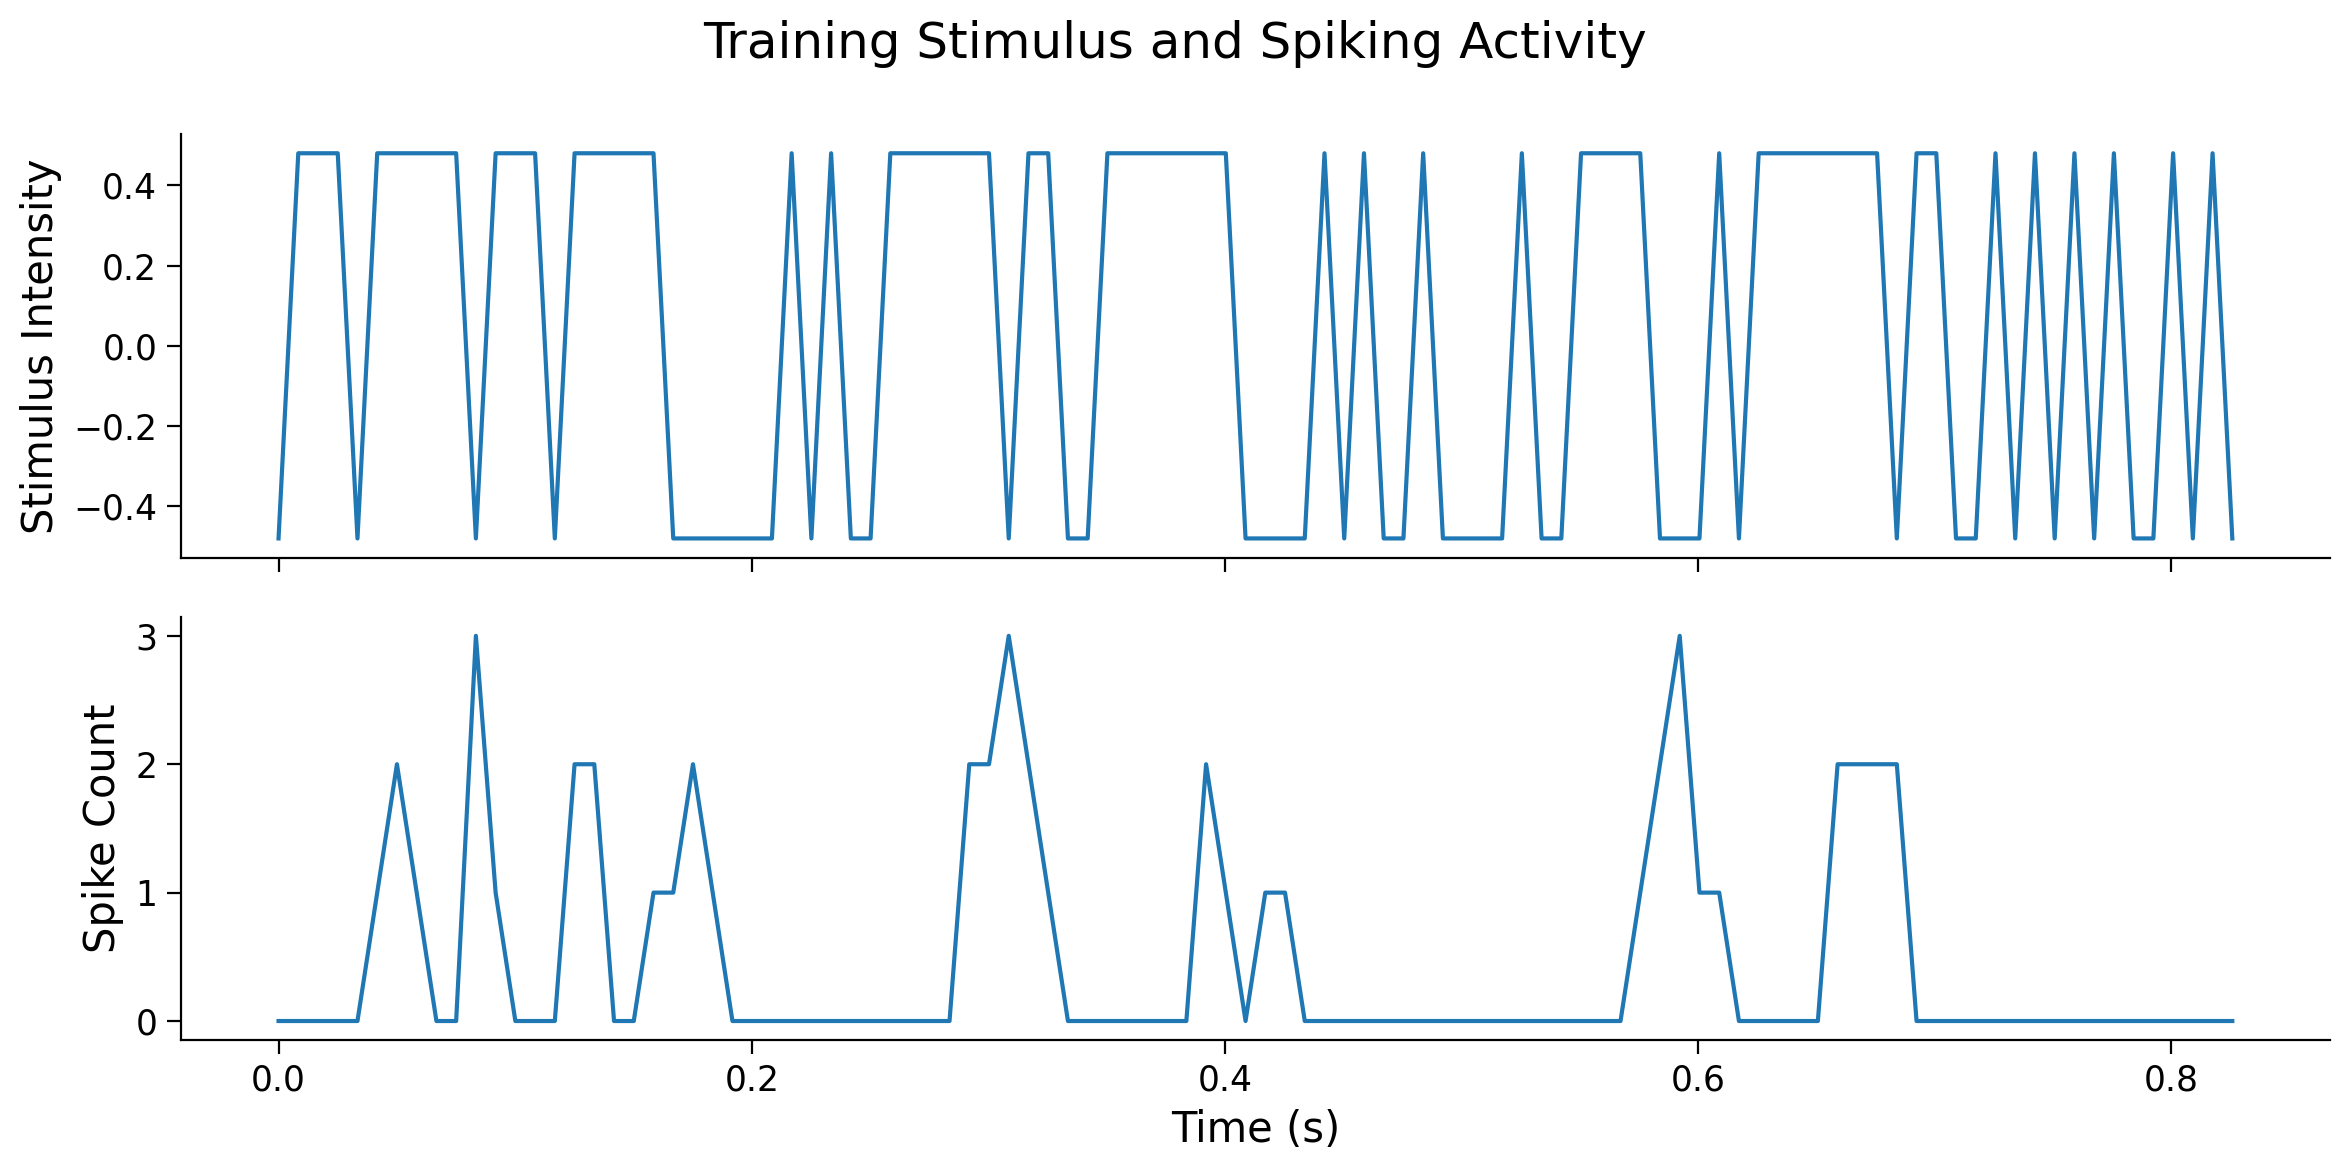

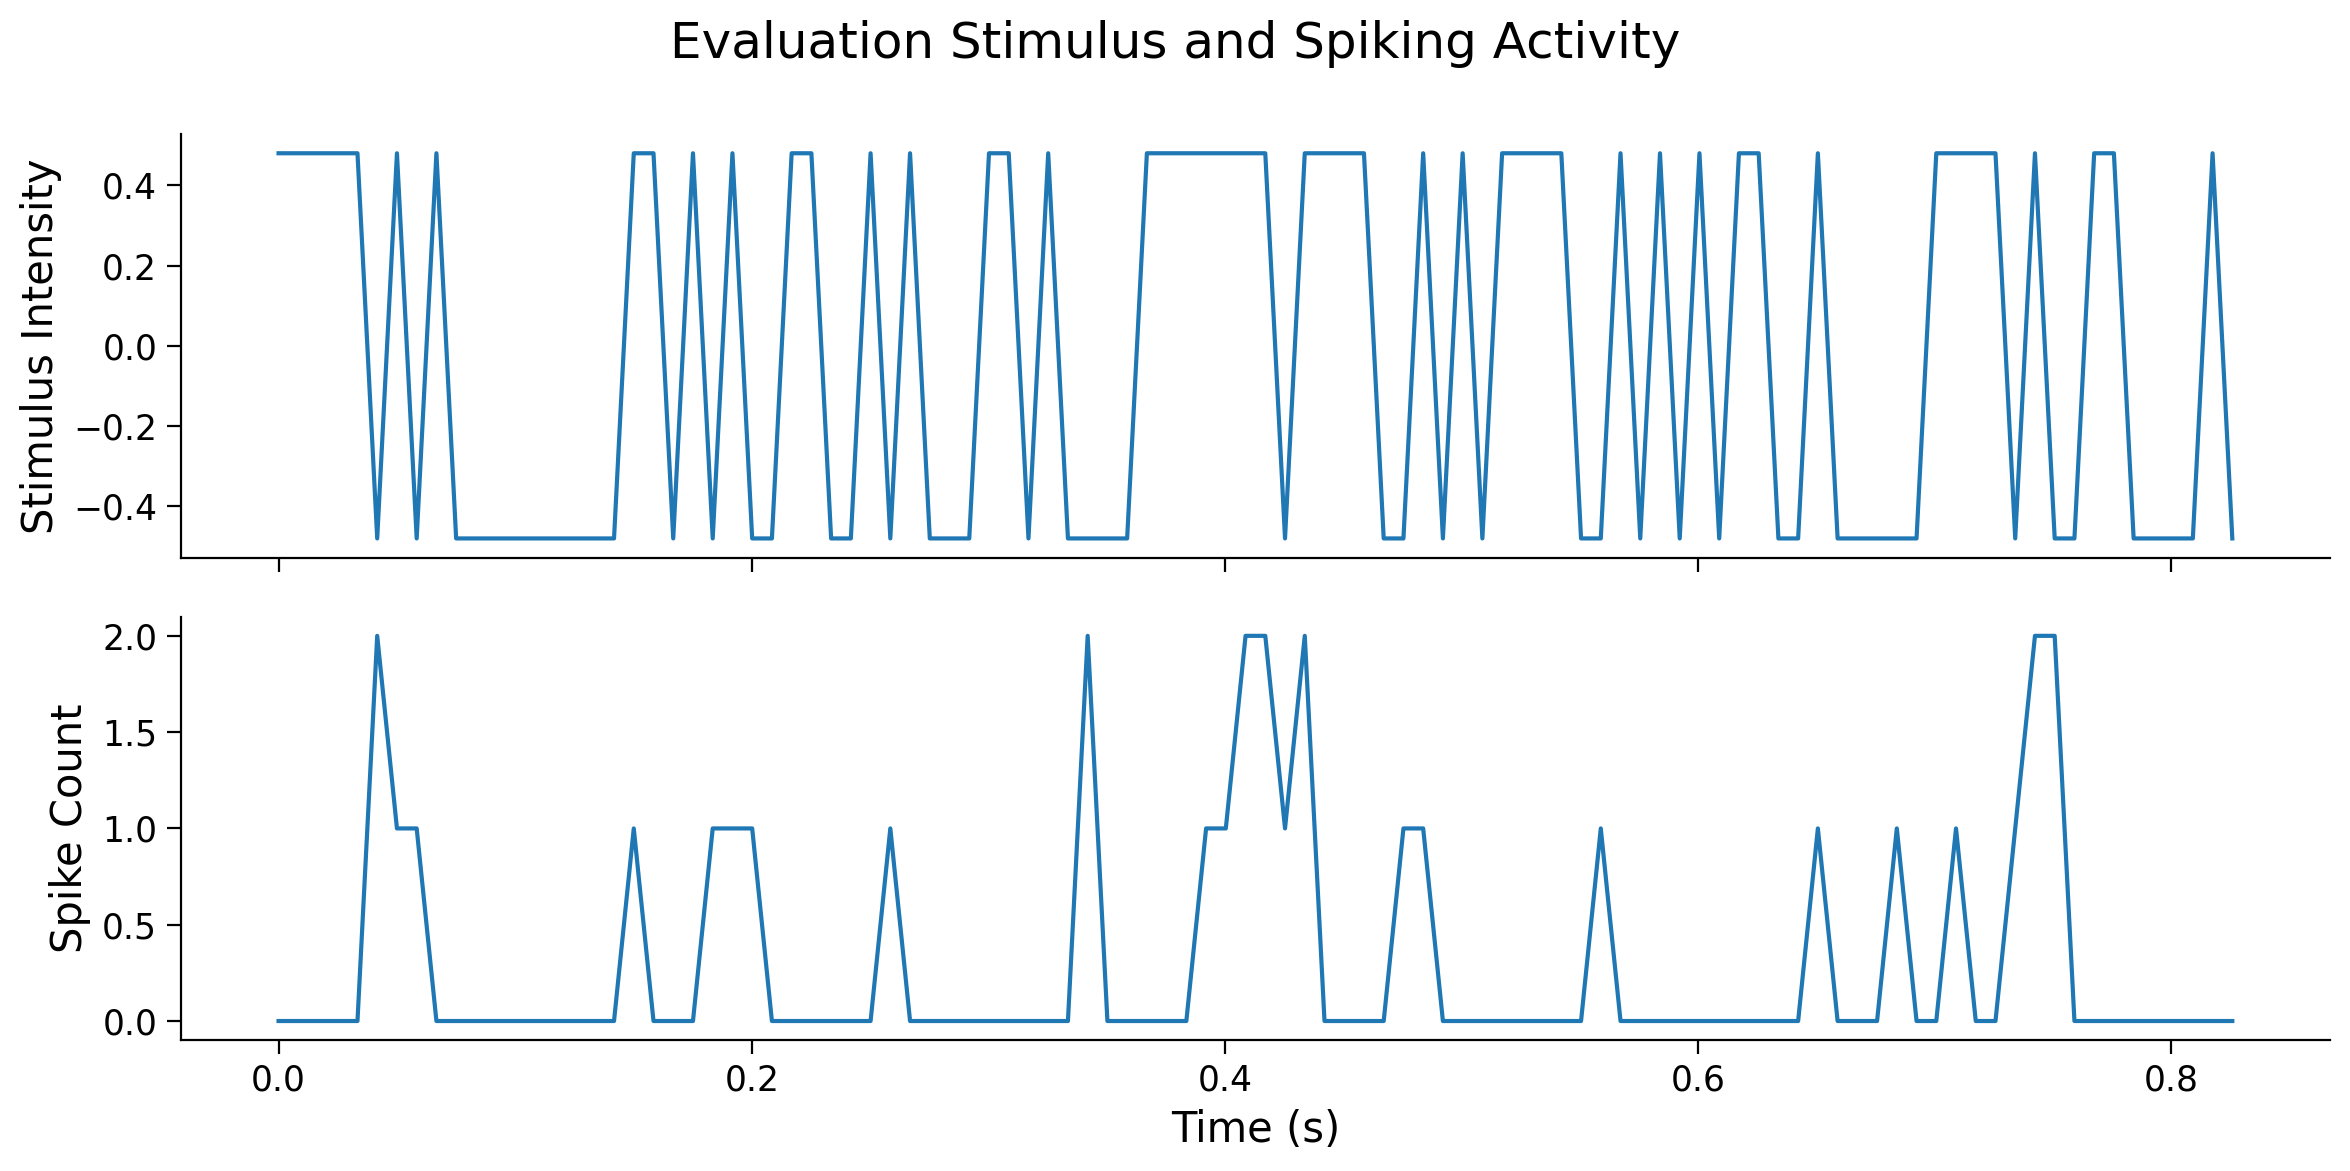

In [ ]:
def plot_stim_and_spikes(stim, spikes, dt_stim, title=''):
  """
  Plot the stimulus and spike counts over time.
  Args:
    stim (1D array): Vector of stimulus intensities
    spikes (1D array): Vector of spike counts
    dt_stim (number): Duration of each time bin
    title (string): Title of the plot (Optional)

  Returns:
    None
  """
  #####################################################################
  # Fill in missing code (...),
  # then remove or comment the line below to test your function
  raise NotImplementedError("Complete the plot_stim_and_spikes function")
  #####################################################################

  # Let's plot the stimulus versus the spiking activity
  # Define the figure (2 subplots)
  fig, axs = plt.subplots(..., figsize=(12,6), sharex=True)

  # We only want to plot a part of the time-series signals (1st 100 points)
  plot_range = np.arange(100)
  # Convert bins to timepoints
  trange = ...

  # In the first subplot, plot the stimulus over time
  axs[0].plot(...)
  # In the second subplot, plot the spiking activity over time
  axs[1].plot(...)

  # Labels and formating
  axs[0].set_ylabel('Stimulus Intensity')
  axs[1].set_ylabel('Spike Count')
  axs[1].set_xlabel('Time (s)')
  plt.suptitle(title)
  plt.show()

# Plot training data
plot_stim_and_spikes(train_stim, train_spikes, dt_stim,
                     title='Training Stimulus and Spiking Activity')

# Plot the Evaluation data as well
plot_stim_and_spikes(eval_stim, eval_spikes, dt_stim,
                     title='Evaluation Stimulus and Spiking Activity')

### Smoothing Spikes to Estimate Firing Rates

A common method for estimating (continuous) firing rates from (discrete) spiking data is to use a gaussian filter to smooth the spikes. This is accomplished by convolving the spike train with the filter. Here, you will create these gaussian filters and smooth the spiking data using `np.convolve()`

The gaussian kernel can be defined as:

$$
K(x, x') = \exp\left(-\frac{- x^2}{2\sigma^2}\right)
$$

Define the kernel function in `gaussian_kernel()` and generate filters
with different standard deviations.

<>:31: SyntaxWarning: invalid escape sequence '\s'
<>:31: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_76002/137647693.py:31: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(tlag, kernel, label=f'$\sigma$: {round(kernel_stds[i]*dt_stim*1000)} ms')


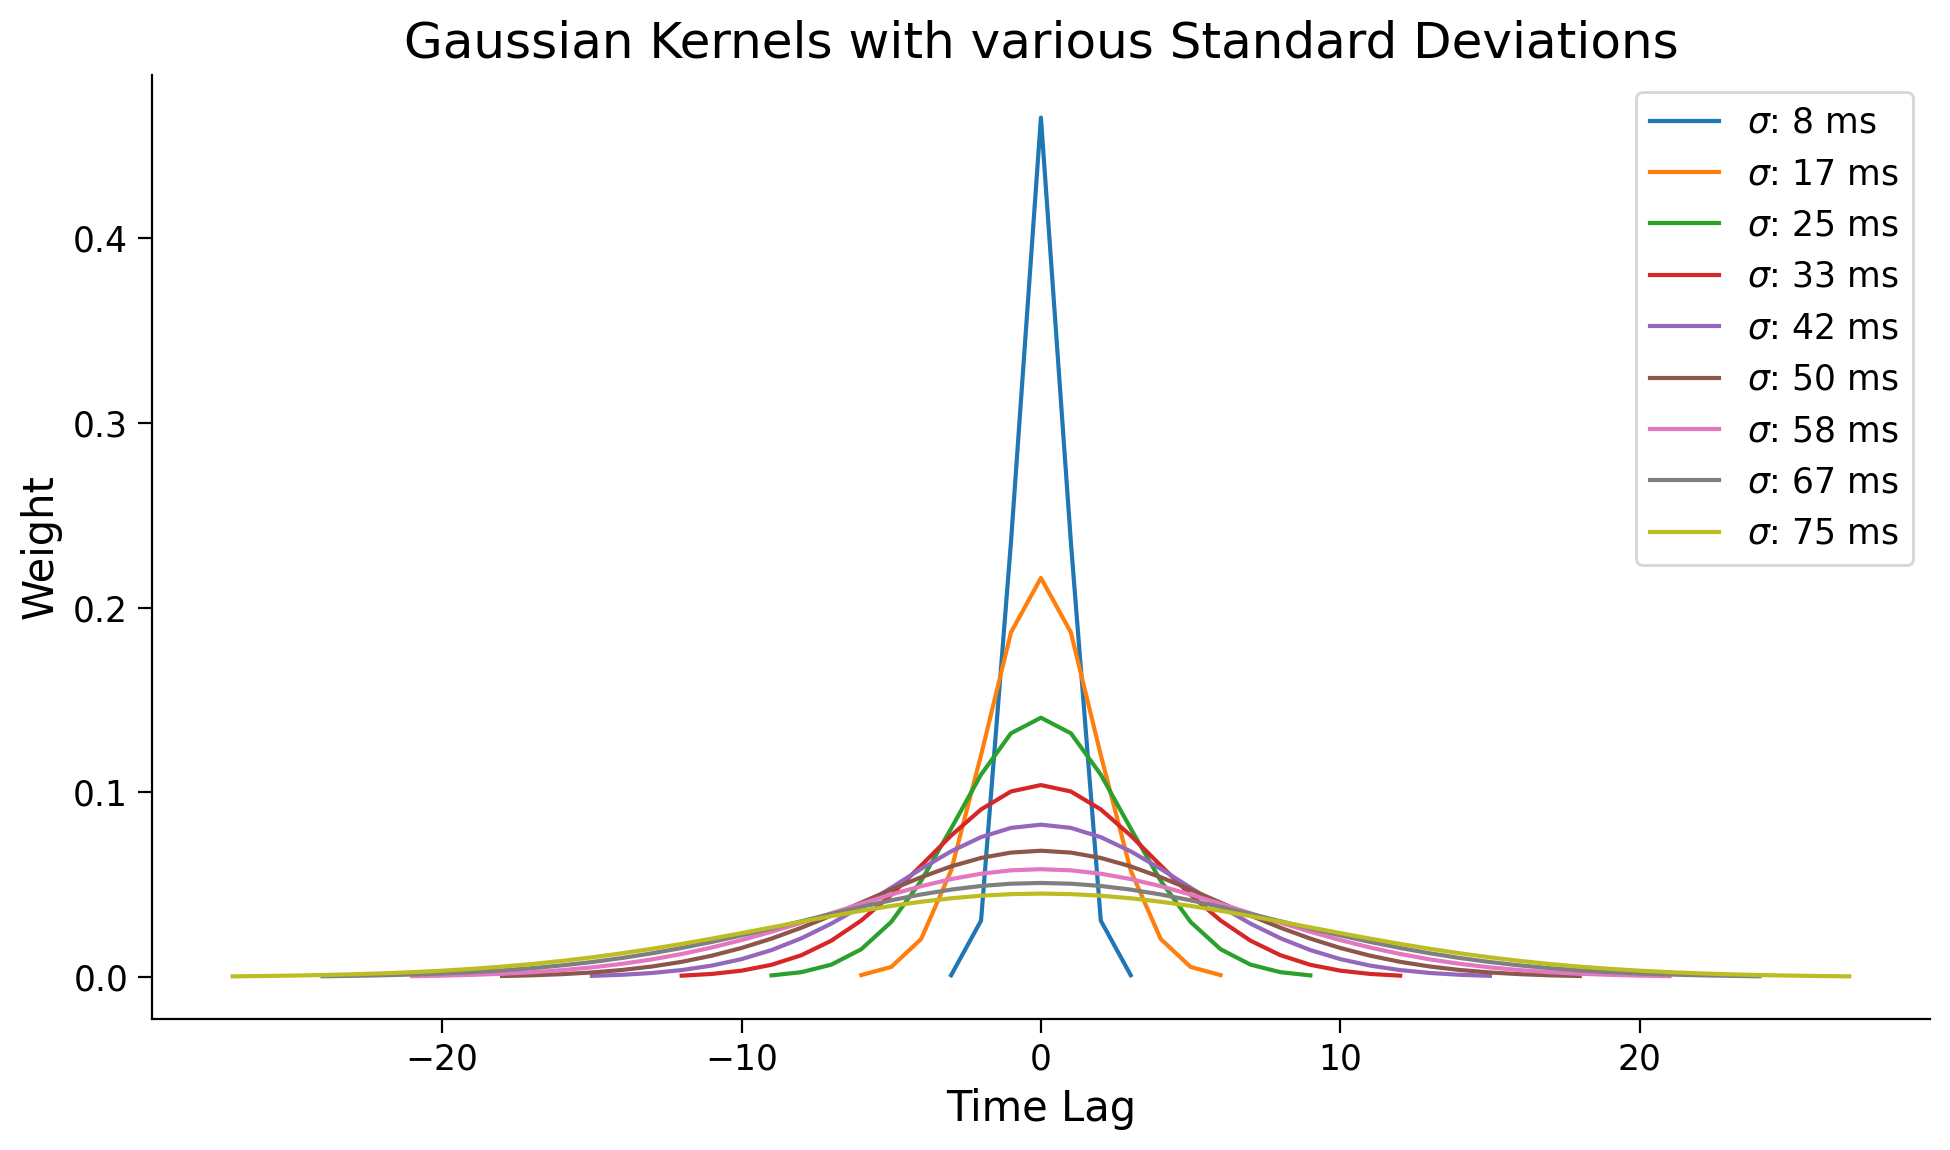

In [ ]:
def gaussian_kernel(kernel_sigma):
  """
  Generates a 1D Gaussian kernel (Centered at 0).

  Args:
    kernel_width (float): Standard deviation of the Gaussian kernel.
    num_points (int): Number of points in the kernel (should be odd for symmetry).

  Returns:
    1D array: Gaussian kernel.
  """

  #####################################################################
  # Fill in missing code (...),
  # then remove or comment the line below to test your function
  raise NotImplementedError("Complete the gaussian_kernel function")
  #####################################################################

  # Define length of filter such that it encompasses 3 std devs
  num_points = 2*(round(3*kernel_sigma))+1
  # Define the filter
  x = np.linspace(-num_points / 2, num_points / 2, num_points)

  # Calculate the gaussian kernel
  kernel = ...

  return kernel / np.sum(kernel)  # Standardize such that it sums to 1

# Vary kernel std devs and get kernel shapes
kernel_stds = np.arange(1, 10)
kernel_results = []
for std in kernel_stds:
  kernel = ...  #TODO
  kernel_results.append(kernel)

# Plot the kernels with varying widths
plt.figure(figsize=(10, 6))
for i, kernel in enumerate(kernel_results):
  tlag = range(-(len(kernel)//2), (len(kernel)//2)+1)
  plt.plot(tlag, kernel,
           label=f'$\sigma$: {round(kernel_stds[i]*dt_stim*1000)} ms')
  plt.xlabel('Time Lag')
  plt.ylabel('Weight')

plt.title('Gaussian Kernels with various Standard Deviations')
plt.legend()
plt.show()


Apply the Gaussian filter to the training and evaluation spike trains using `np.convolve()` and plot the estimated rates against the spiking activity


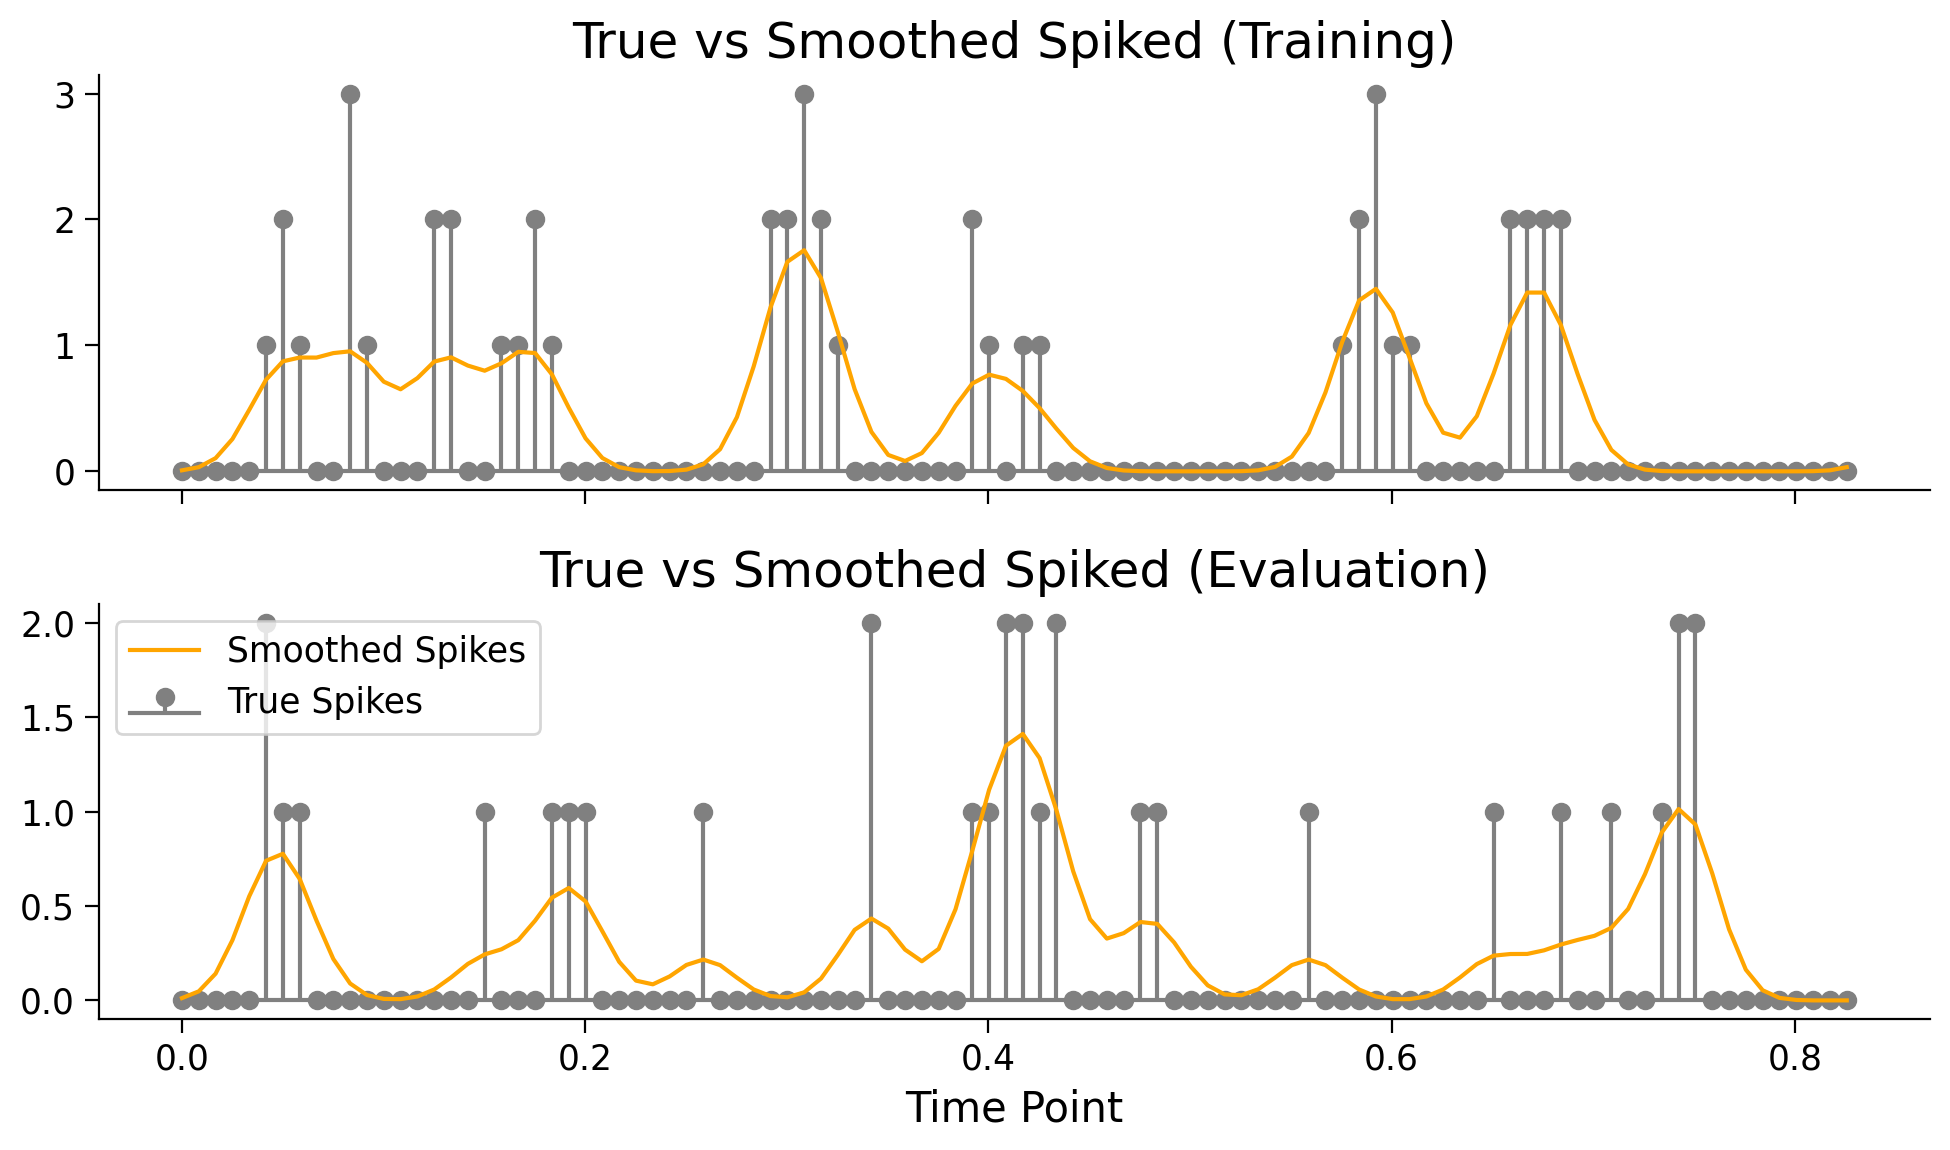

In [ ]:
from scipy.ndimage import gaussian_filter1d

# Create function to smooth spikes using np.convolve()
def smooth_spikes(spikes, kernel):
  """
  Smooth spikes by convolving with a gaussian kernel.

  Args:
    spikes (1D array): Vector of spike counts
    kernel (1D array): Gaussian kernel

  Returns:
    1D array: Smoothed spike counts
  """
  # HINT: Look at the docs for np.convolve to see what arg can be set so the
  #       output is the same length as the input.

  #####################################################################
  # Fill in missing code (...),
  # then remove or comment the line below to test your function
  raise NotImplementedError("Complete the smooth_spikes function")
  #####################################################################

  return np.convolve(...)

# Create a gaussian kernel
kernel = gaussian_kernel(kernel_sigma=2)
# Smooth the training spikes
smooth_train_spikes = smooth_spikes(...) #TODO
# Smooth the evaluation spikes
smooth_eval_spikes = smooth_spikes(...)  #TODO


# We only want to plot a part of the time-series signals
plot_range = np.arange(100)
trange = plot_range * dt_stim # Converts pure indices into timepoints

# Training set: Plot true spikes
fig, axs = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
lines1 = axs[0].stem(trange, train_spikes[plot_range], label='True Spikes')
# Training set: Plot smoothed spikes
axs[0].plot(trange, smooth_train_spikes[plot_range],
            label='Smoothed Spikes', color='orange')

# Repeat for evaluation data
lines2 = axs[1].stem(trange, eval_spikes[plot_range], label='True Spikes')
axs[1].plot(trange, smooth_eval_spikes[plot_range],
            label='Smoothed Spikes', color='orange')


# FORMATTING
plt.setp(lines1, color=".5")
plt.setp(lines2, color=".5")
lines1[-1].set_zorder(1)
lines2[-1].set_zorder(1)
plt.legend()
axs[1].set_xlabel('Time Point')
axs[0].set_title('True vs Smoothed Spiked (Training)')
axs[1].set_title('True vs Smoothed Spiked (Evaluation)')
plt.show()

Now, let's look at how the standard deviation of the gaussian kernel affects the estimated firing rates:

<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_76002/256738322.py:22: SyntaxWarning: invalid escape sequence '\s'
  label=f'Smoothed ($\sigma$={round(std_dev*1000*dt_stim)} ms)')


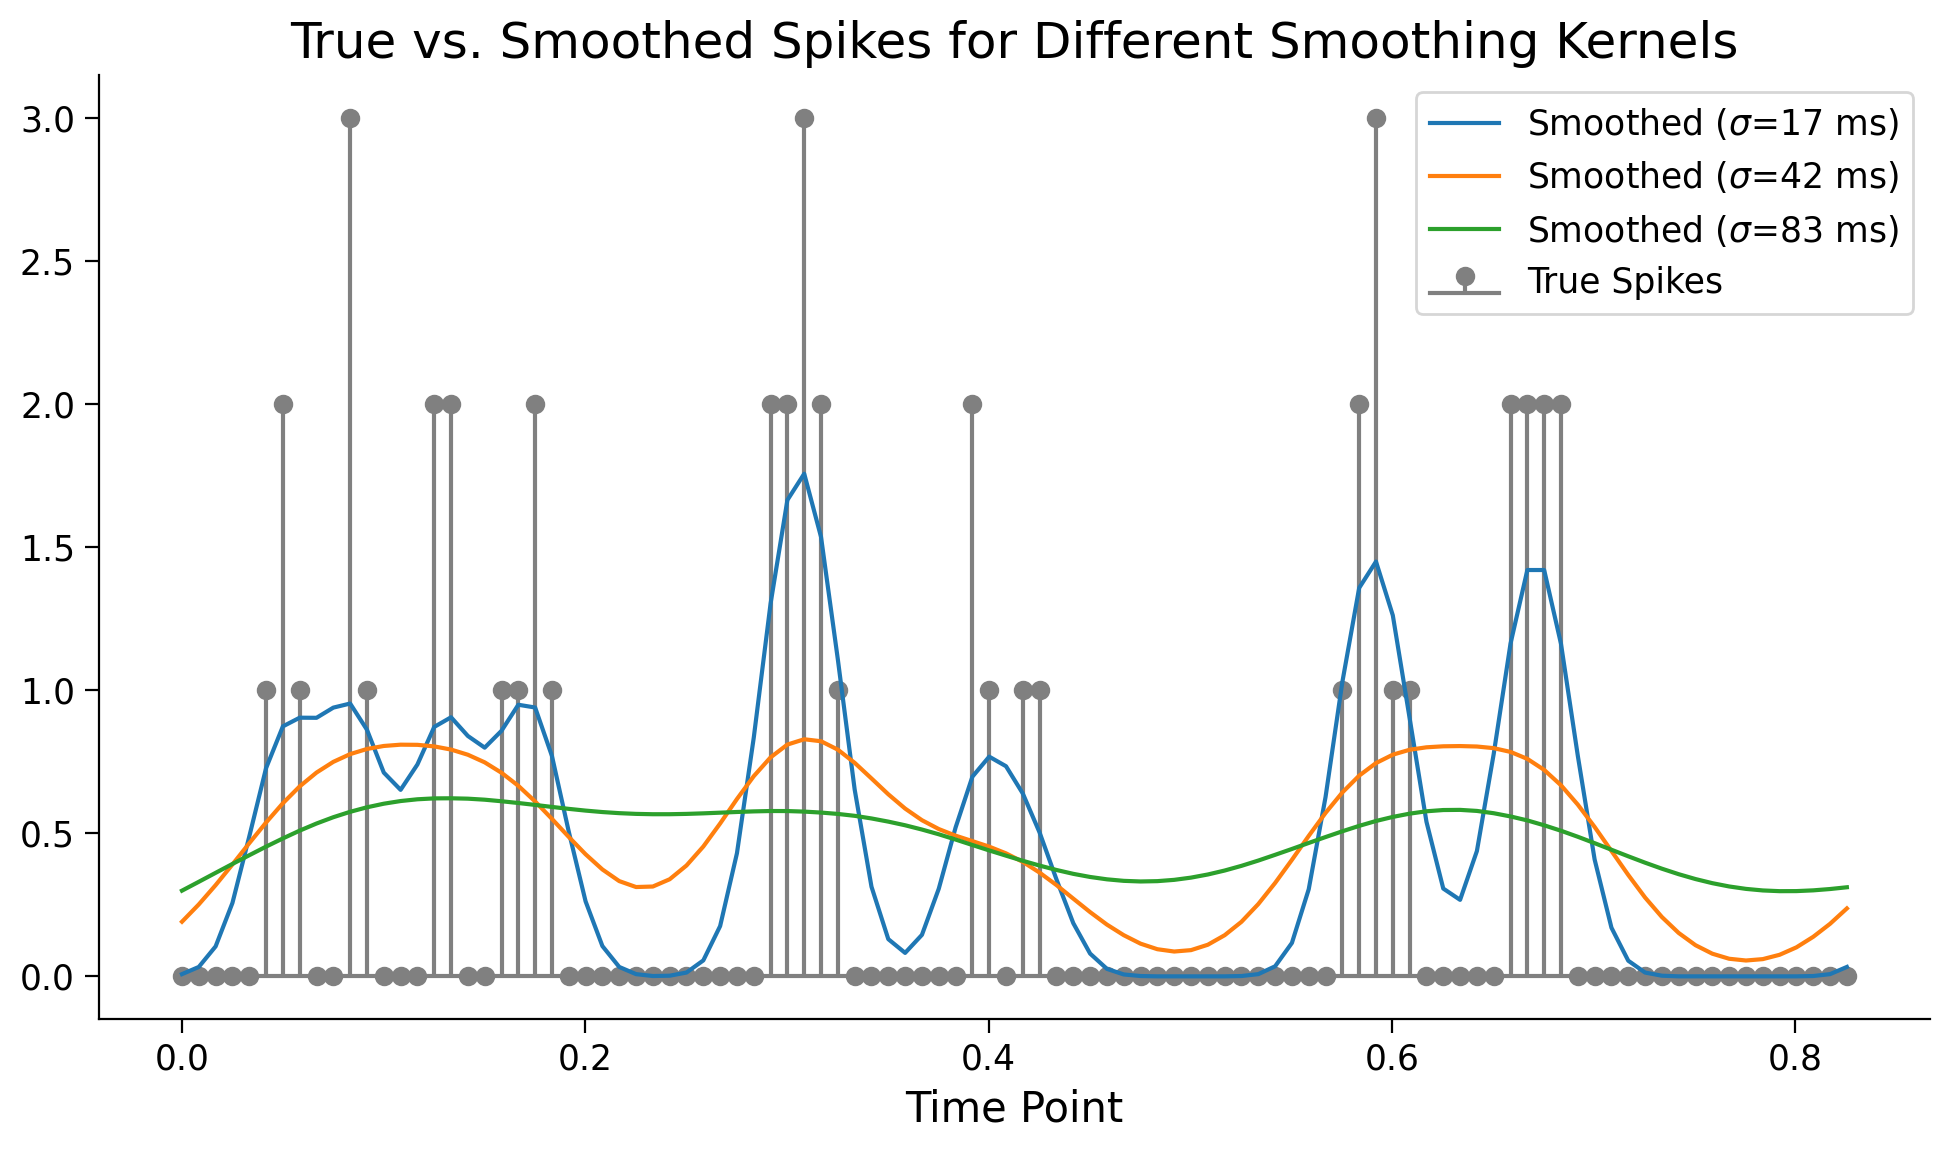

In [ ]:
kernel_stds_to_plot = [2, 5, 10]

smooth_spikes_sweep = []

for i, std_dev in enumerate(kernel_stds_to_plot):
  # Create a gaussian kernel
  kernel = gaussian_kernel(kernel_sigma=std_dev)
  # Smooth spikes
  smooth_spikes_sweep.append(smooth_spikes(train_spikes, kernel))

# Create figure
plt.figure(figsize=(10, 6))
plot_range = np.arange(100)
trange = plot_range * dt_stim
# Plot true spikes
lines = plt.stem(trange, train_spikes[plot_range], label='True Spikes')
plt.setp(lines, color=".5")

# Plot smoothed spikes
for rates, std_dev in zip(smooth_spikes_sweep, kernel_stds_to_plot):
  plt.plot(trange, rates[plot_range],
           label=f'Smoothed ($\sigma$={round(std_dev*1000*dt_stim)} ms)')

# Formatting
plt.title(f'True vs. Smoothed Spikes for Different Smoothing Kernels')
plt.xlabel('Time Point')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

#### <font color="red">Question:</font>
What are the tradeoffs of using a smaller vs larger standard deviation?

### Coding Exercise 1.1: Create design matrix

Our goal is to predict the cell's activity from the stimulus intensities preceding it. That will help us understand how RGCs process information over time. To do so, we first need to create the *design matrix* for this model, which organizes the stimulus intensities in matrix form such that the $i$th row has the stimulus frames preceding timepoint $i$.

In this exercise, we will create the design matrix $\mathbf{X}$ using $d=25$ time lags. That is, $\mathbf{X}$ should be a $T \times d$ matrix. $d = 25$ (about 200 ms) is a choice we're making based on our prior knowledge of the temporal window that influences RGC responses. In practice, you might not know the right duration to use.

The last entry in row `t` should correspond to the stimulus that was shown at time `t`, the entry to the left of it should contain the value that was shown one time bin earlier, etc. Specifically, $X_{ij}$ will be the stimulus intensity at time $i + d - 1 - j$.

Note that for the first few time bins, we have access to the recorded spike counts but not to the stimulus shown in the recent past. For simplicity we are going to assume that values of `stim` are 0 for the time lags prior to the first timepoint in the dataset. This is known as "zero-padding", so that the design matrix has the same number of rows as the response vectors in `spikes`.

Your task is is to complete the function below to:

  - make a zero-padded version of the stimulus
  - initialize an empty design matrix with the correct shape
  - **fill in each row of the design matrix, using the zero-padded version of the stimulus**

To visualize your design matrix (and the corresponding vector of spike counts), we will plot a "heatmap", which encodes the numerical value in each position of the matrix as a color. The helper functions include some code to do this.

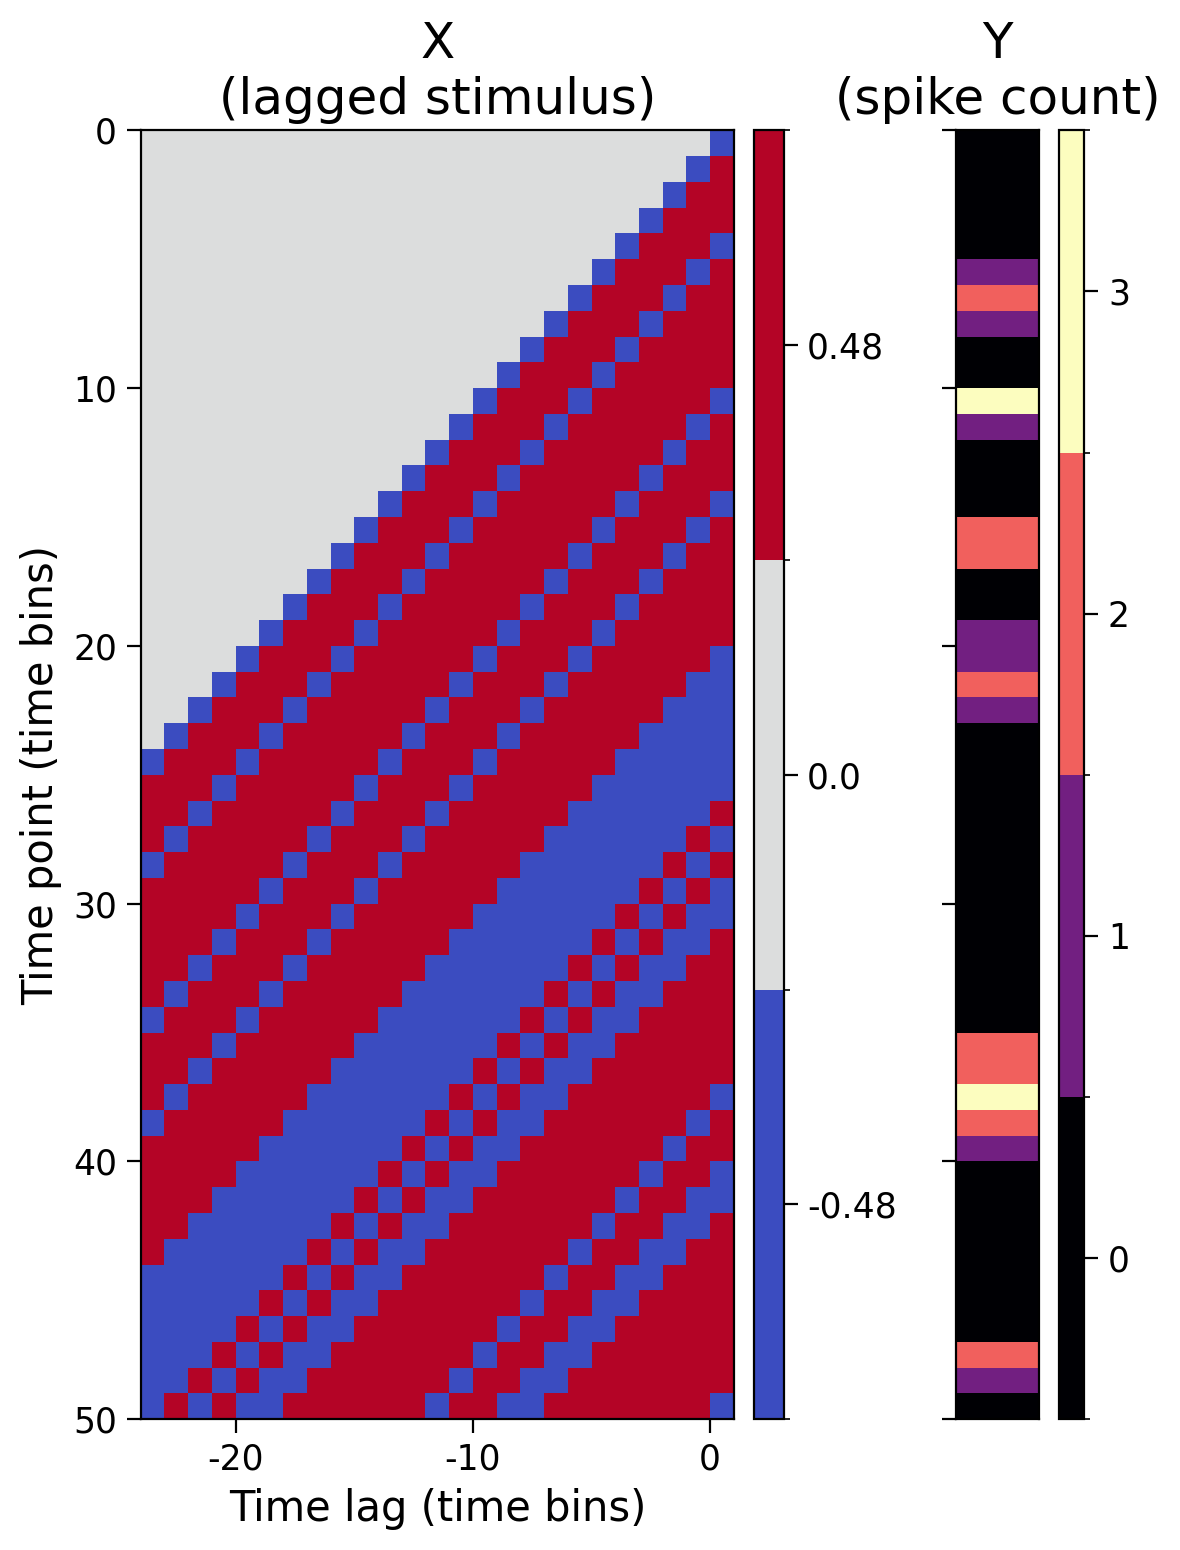

In [ ]:
def make_design_matrix(stim, d=25):
  """Create time-lag design matrix from stimulus intensity vector.

  Args:
    stim (1D array): Stimulus intensity at each time point.
    d (number): Number of time lags to use.

  Returns
    X (2D array): GLM design matrix with shape T, d

  """

  #####################################################################
  # Fill in missing code (...),
  # then remove or comment the line below to test your function
  raise NotImplementedError("Complete the make_design_matrix function")
  #####################################################################

  # Create version of stimulus vector with zeros before onset
  padded_stim = np.concatenate([np.zeros(d - 1), stim])

  # Construct a matrix where each row has the d frames of
  # the stimulus preceding and including timepoint t
  T = len(...)  # Total number of timepoints (hint: number of stimulus frames)
  X = np.zeros((T, d))
  for t in range(T):
      X[t] = ...

  return X

# Make design matrix
X = make_design_matrix(train_stim, d=25)

# Visualize
plot_glm_matrices(X, train_spikes, nt=50)

## Section 1.2: Fit Linear-Gaussian regression model

First, we will use the design matrix to compute the maximum likelihood estimate for a linear-Gaussian GLM (aka "general linear model"). The maximum likelihood estimate of $\theta$ in this model can be solved analytically using the equation you learned about from Lecture 1:

\begin{equation}
\boldsymbol{\hat \theta} = (\mathbf{X}^{\top}\mathbf{X})^{-1}\mathbf{X}^{\top}\mathbf{y}
\end{equation}

Before we can apply this equation, we need to augment the design matrix to account for the mean of $y$, because the spike counts are all $\geq 0$. We do this by adding a constant column of 1's to the design matrix, which will allow the model to learn an additive offset weight. We will refer to this additional weight as $b$ (for bias), although it is alternatively known as a "DC term" or "intercept".

In [ ]:
def add_bias_to_design_matrix(stim, spikes, d=25):
  """
  Create time-lag design matrix from stimulus intensity vector with bias term.

  Args
    stim (1D array): Stimulus intensity at each time point.
    spikes (1D array): Spike counts at each time point.
    d (number): Number of time lags to use.

  Returns
    (2D array): Complete design matrix with bias
  """

  ##########################################################################
  # Fill in missing code (...) and then comment or remove the error to test
  raise NotImplementedError("Complete the add_bias_to_design_matrix function")
  ##########################################################################

  # Create vector of ones for the bias term
  constant = ...
  # Get the design matrix from the stimulus
  X = make_design_matrix(stim, d=d)
  # Combine the bias term with the design matrix
  X_with_bias = np.column_stack(...)
  return X_with_bias

# Build the full design matrix
y = train_spikes
X = add_bias_to_design_matrix(train_stim, train_spikes, d=25)

# Get the MLE weights for the LG model
theta_lg = ...


Plot the resulting maximum likelihood filter estimate (just the 25-element weight vector $\theta$ on the stimulus elements, not the DC term $b$).

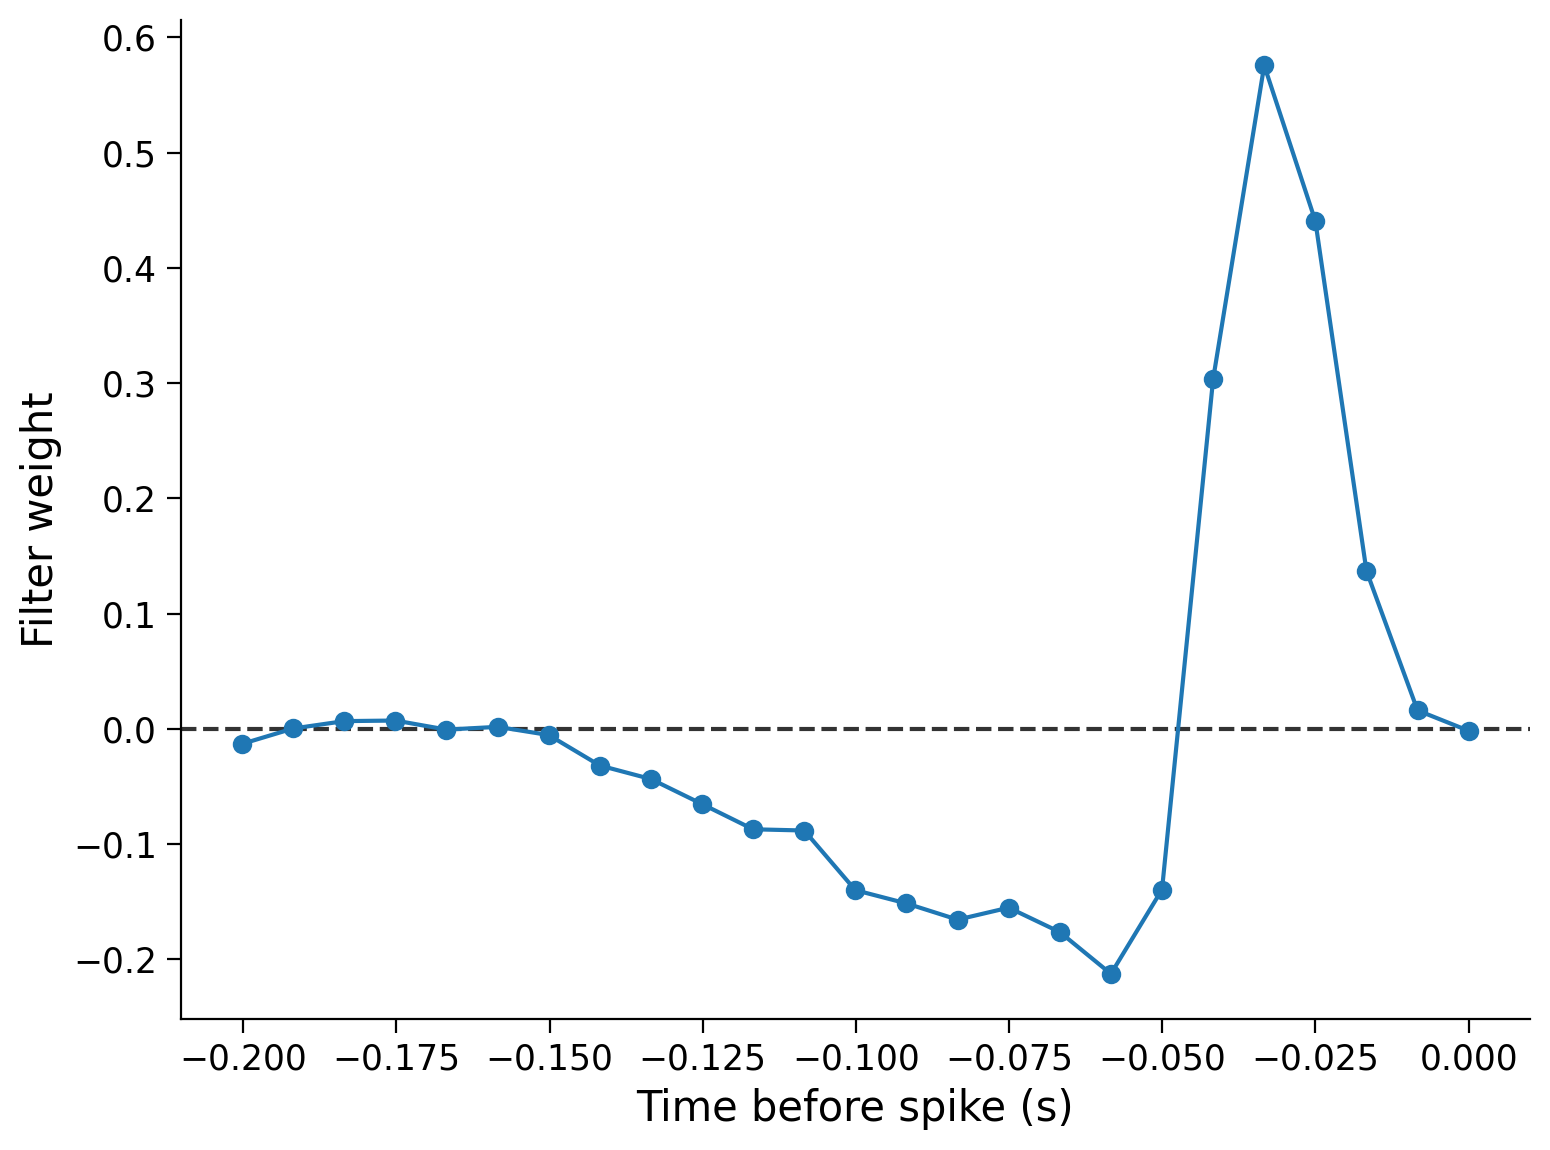

In [ ]:
lg_filter = theta_lg[1:] # Slice from 1 to leave out bias term
plot_spike_filter(lg_filter, dt_stim)

#### <font color="red">Questions:</font>
What does the shape of this filter tell us?

Which time points are important for predicting spiking activity?

### Coding Exercise 1.2: Predict spike counts with Linear-Gaussian model

Now we are going to put these pieces together and write a function that outputs a predicted spike count for each timepoint using the stimulus information.

Your steps should be:

- Create the complete design matrix
- Obtain the MLE weights ($\boldsymbol{\hat \theta}$)
- Compute $\mathbf{\hat y} = \mathbf{X}\boldsymbol{\hat \theta}$

In [ ]:
def calculate_lg_preds(X, theta):
  """
  Compute the predicted spike counts given the stimulus for a Linear-Gaussian
  model.

  Args:
    X (2D array): Complete design matrix with bias
    theta (1D array): Filter

  Returns:
    yhat (1D array): Predicted spikes at each timepoint.
  """

  ##########################################################################
  # Fill in missing code (...) and then comment or remove the error to test
  raise NotImplementedError("Complete the calculate_lg_preds function")
  ##########################################################################

  return ...

def predict_spike_counts_lg(stim, spikes, d=25):
  """Compute a vector of predicted spike counts given the stimulus.

  Args:
    stim (1D array): Stimulus values at each timepoint
    spikes (1D array): Spike counts measured at each timepoint
    d (number): Number of time lags to use.

  Returns:
    yhat (1D array): Predicted spikes at each timepoint.

  """
  ##########################################################################
  # Fill in missing code (...) and then comment or remove the error to test
  raise NotImplementedError("Complete the predict_spike_counts_lg function")
  ##########################################################################

  # Create the design matrix
  y = spikes
  X = add_bias_to_design_matrix(stim, spikes, d)

  # Get the MLE weights for the LG model
  theta = ...

  # Compute predicted spike counts
  yhat = calculate_lg_preds(X, theta)

  return yhat, theta


# Predict spike counts for training set
predicted_counts, theta_lg = predict_spike_counts_lg(train_stim,
                                                     train_spikes,
                                                     d=25)


Plot the predicted activity against the true spiking data

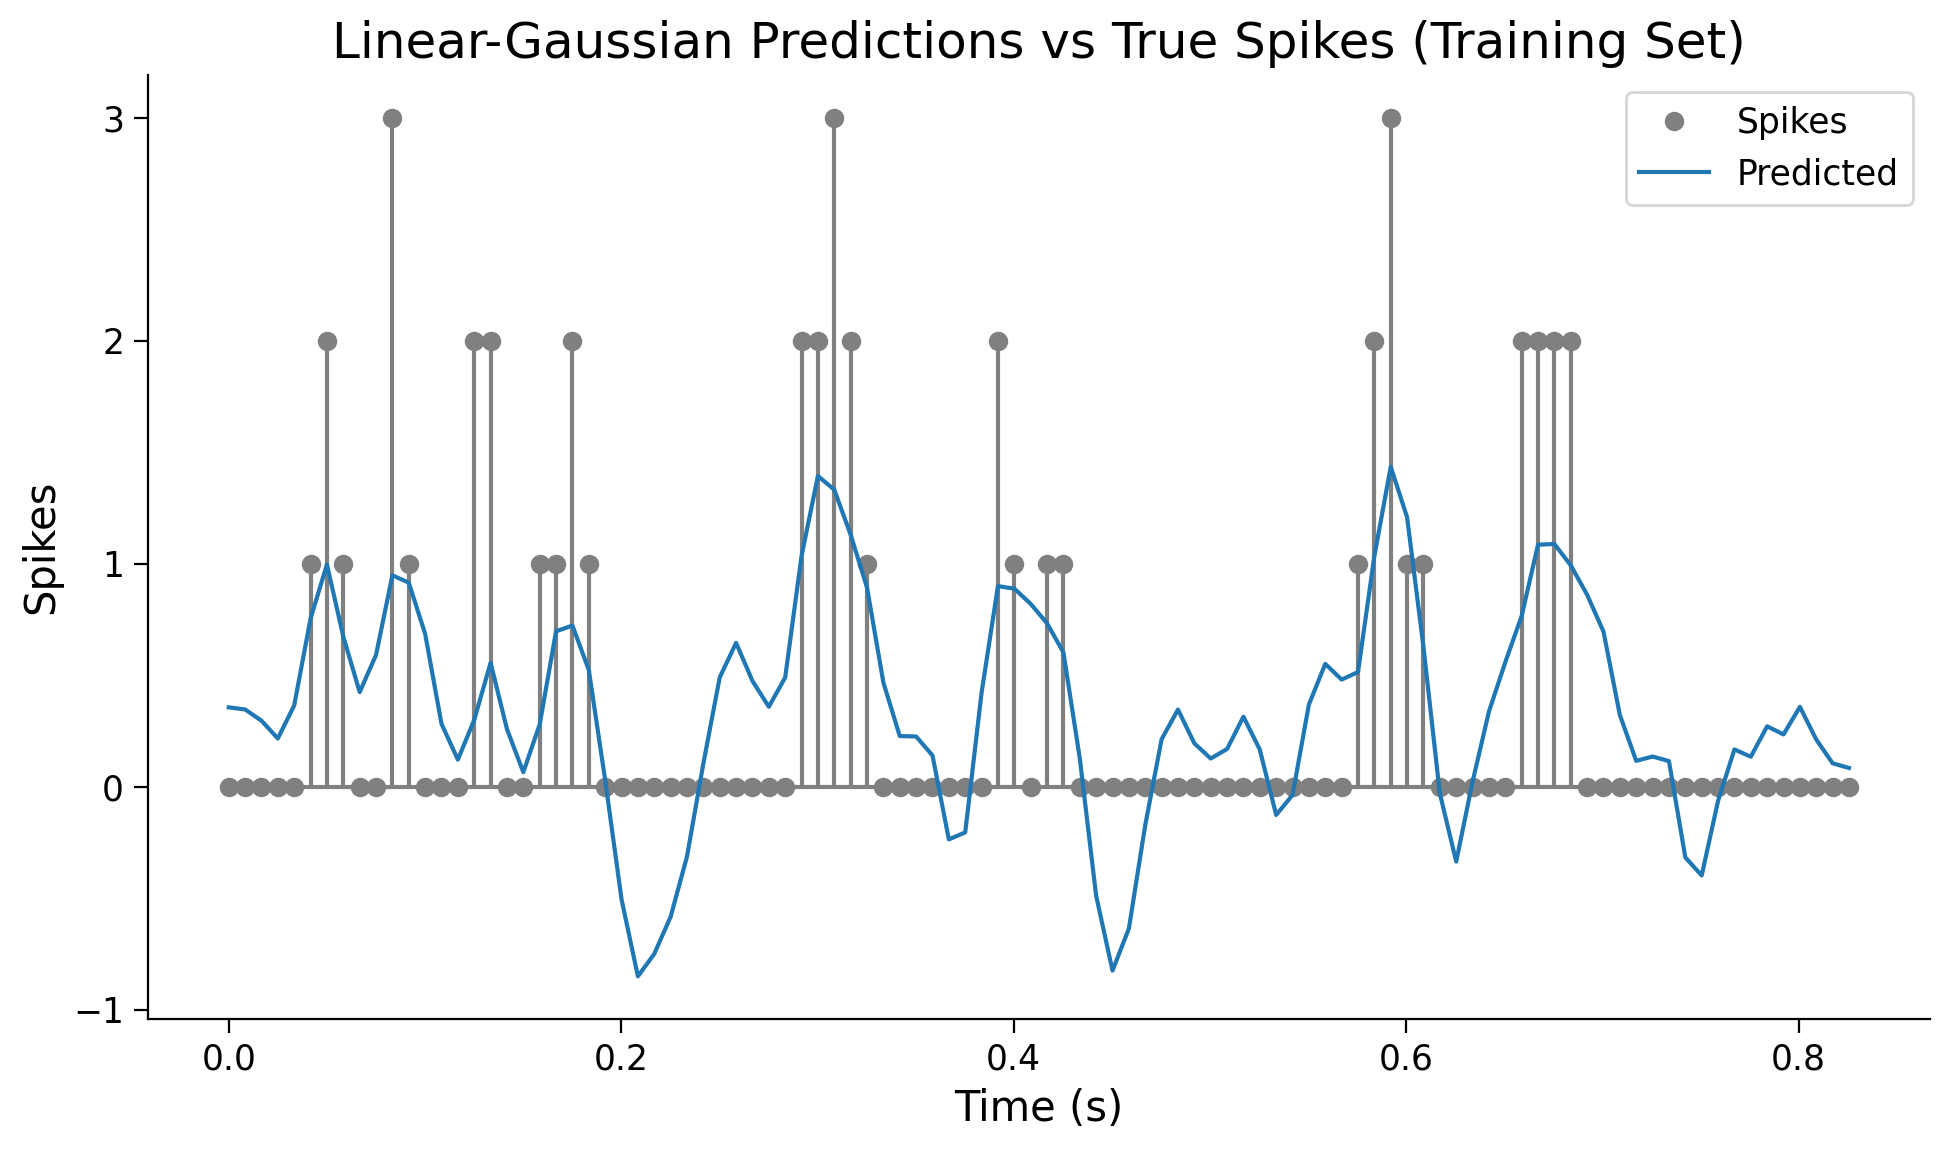

In [ ]:
def plot_spikes_with_prediction(spikes, predicted_spikes, dt,
                                nt=100, t0=0, show=True, **kws):
  """Plot actual and predicted spike counts.

  Args:
    spikes (1D array): Vector of actual spike counts
    predicted_spikes (1D array): Vector of predicted spike counts
    dt (number): Duration of each time bin.
    nt (number): Number of time bins to plot
    t0 (number): Index of first time bin to plot.
    show (boolean): To plt.show or not the plot.
    kws: Pass additional keyword arguments to plot()

  """

  ##########################################################################
  # Fill in missing code (...) and then comment or remove the error to test
  raise NotImplementedError("Complete the plot_spikes_with_prediction "
  "function")
  ##########################################################################

  # Create the series of timepoints to plot (from t0 to t0+nt)
  t = np.arange(t0, t0 + nt) * dt

  # Create figure
  f, ax = plt.subplots(figsize=(10,6))
  # Plot the true spiking data
  lines = ax.stem(...)
  # Plot model predictions
  yhat, = ax.plot(..., **kws)

  # Formatting and labeling
  plt.setp(lines, color=".5")
  lines[-1].set_zorder(1)
  kws.setdefault("linewidth", 3)
  ax.set(
      xlabel="Time (s)",
      ylabel="Spikes",
  )
  ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
  ax.legend([lines[0], yhat], ["Spikes", "Predicted"])
  if show:
    plt.show()

# Visualize
plot_spikes_with_prediction(train_spikes, predicted_counts, dt_stim, show=False)
plt.title('Linear-Gaussian Predictions vs True Spikes (Training Set)')
plt.show()

Is this a good model? The prediction line more-or-less follows the bumps in the spikes, but it never predicts as many spikes as are actually observed. And, more troublingly, it's predicting *negative* spikes for some time points.

You will see in the next section that the Poisson GLM will help to address these failures.

### Evaluating Linear Gaussian Model Performance for a varying number of lagged features

In Lecture 1, we learned about the Mean Squared Error (MSE) which measures the
average squared difference between estimated values (predictions) and the
actual values.

Here, we will quantitatively evaluate LG models with different amounts of
lagged features using the MSE metric. It's worth noting that using MSE is not the standard method for evaluating model fit because of its gaussian assumptions, however we use it here for ease.

Let's start by defining the MSE metric and calculating it for the model fit on the training set:

In [ ]:
# Get MSE between predicted and true spikes
# Have students define the mean squared error!!!!!!
def mean_squared_error(y_true, y_hat):
  """
  Calculate the mean squared error between two vectors.

  Args:
    y_true (1D array): Vector of true values
    y_hat (1D array): Vector of predicted

  Returns:
    mse (number): Mean squared error
  """

  ##########################################################################
  # Fill in missing code (...) and then comment or remove the error to test
  raise NotImplementedError("Complete the mean_squared_error")
  ##########################################################################

  return ...

# Calculate the MSE on the LG fit
mse_train = mean_squared_error(train_spikes, predicted_counts)
print(f"MSE on training set: {mse_train:.4f}")

MSE on training set: 0.2652


Next, we will define the `evaluate_model_with_lags()` function to evaluate either model (LG or LNP later) for various lagged features:

In [ ]:
def evaluate_model_with_lags(
    fit_function, predict_function,
    train_stim, train_spikes,
    eval_stim, eval_spikes,
    lagged_feat_nums=np.linspace(5, 50, 20, dtype=np.int16)
  ):
  """
  Evaluate a model with different numbers of lagged features.

  Args
    fit_function (function): Function to fit the model params
    predict_function (function): Function to predict spike counts
    train_stim (1D array): Stimulus values to fit the model on
    train_spikes (1D array): Spike counts to fit the model on
    eval_stim (1D array): Stimulus values to evaluate the model on
    eval_spikes (1D array): Spike counts to evaluate the model on
    lagged_feat_nums (list): List of numbers of lagged features to use
                             (Default): 20 lags from 5 to 50

  Returns
    mse_values (list): List of MSE values for each number of lagged features
    predictions (list): List of predicted spike counts for each number of
                        lagged features
    params (list): List of MLE parameters for each number of lagged features
  """
  ##########################################################################
  # Fill in missing code (...) and then comment or remove the error to test
  raise NotImplementedError("Complete the evaluate_model_with_lags")
  ##########################################################################

  mse_values = []
  predictions = []
  params = []

  for d in lagged_feat_nums:
    # Fit the model params using training data
    _, theta = ... #TODO

    # Evaluate the model using evaluation data
    X_eval = add_bias_to_design_matrix(eval_stim, eval_spikes, d)
    predicted_counts = ... #TODO

    # Calculate MSE
    mse = ... #TODO

    mse_values.append(mse)
    predictions.append(predicted_counts)
    params.append(theta)

  return mse_values, predictions, params

# Define lagged_feat_nums (20 different lags from 5 lags to 50 lags)
lagged_feat_nums = np.linspace(5, 50, 20, dtype=np.int16)

# Call the new function with the existing data
lg_MSEs, lg_predictions, lg_params = evaluate_model_with_lags(
    fit_function=predict_spike_counts_lg,
    predict_function=calculate_lg_preds,
    train_stim=train_stim,
    train_spikes=train_spikes,
    eval_stim=eval_stim,
    eval_spikes=eval_spikes,
    lagged_feat_nums=lagged_feat_nums
)

We can now observe how the MSE changes as the number of lagged features increases:

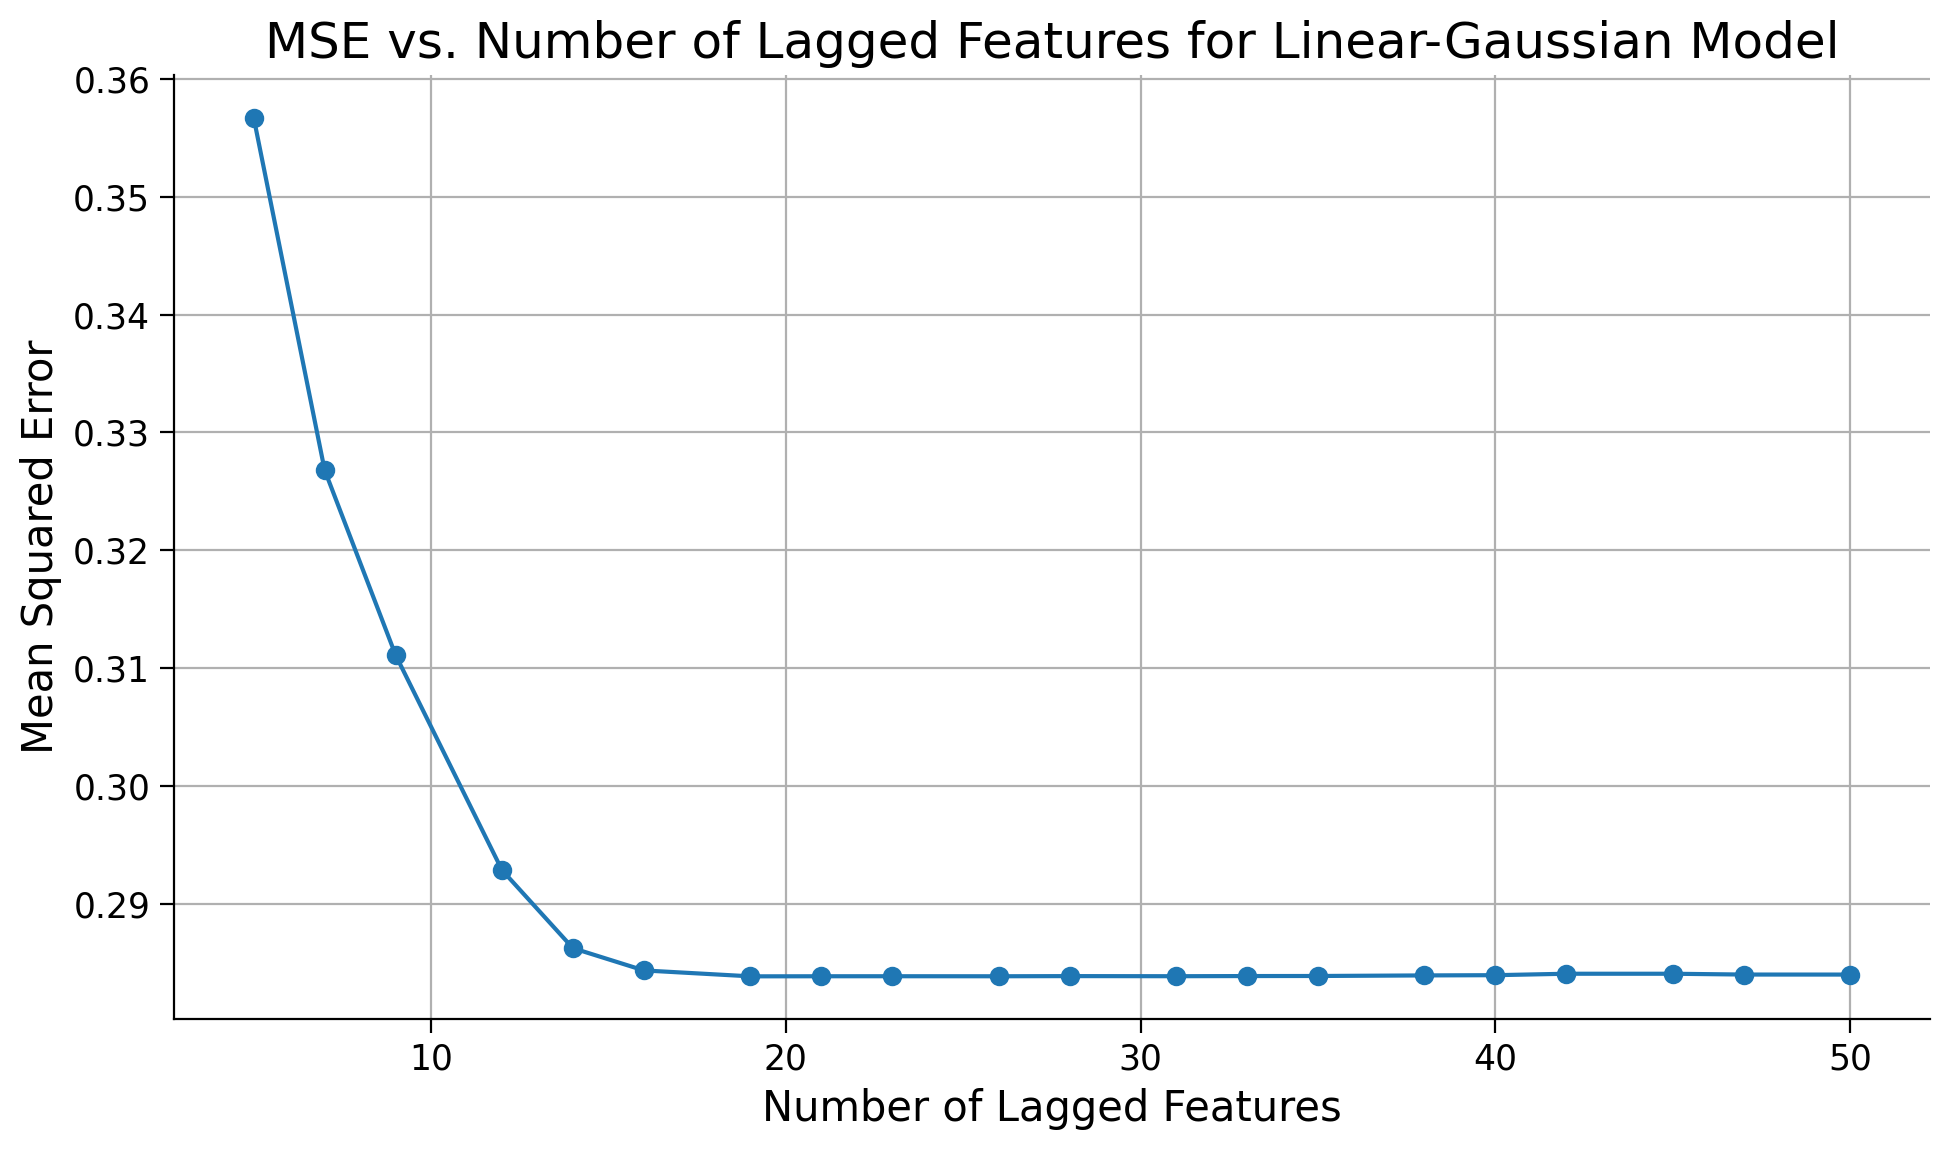

In [ ]:
# Plot MSE vs number of lagged features
plt.figure(figsize=(10, 6))
plt.plot(lagged_feat_nums, lg_MSEs, marker='o', linestyle='-')

# Labels and formatting
plt.xlabel('Number of Lagged Features')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs. Number of Lagged Features for Linear-Gaussian Model')
plt.grid(True)
plt.show()

#### <font color="red">Question:</font>
How does the MSE change with the number of lagged features used?

Plot the filters for a model with a low, medium, and high amount of lagged
features. For each model, also plot the predicted vs true activity for the
evaluation set.

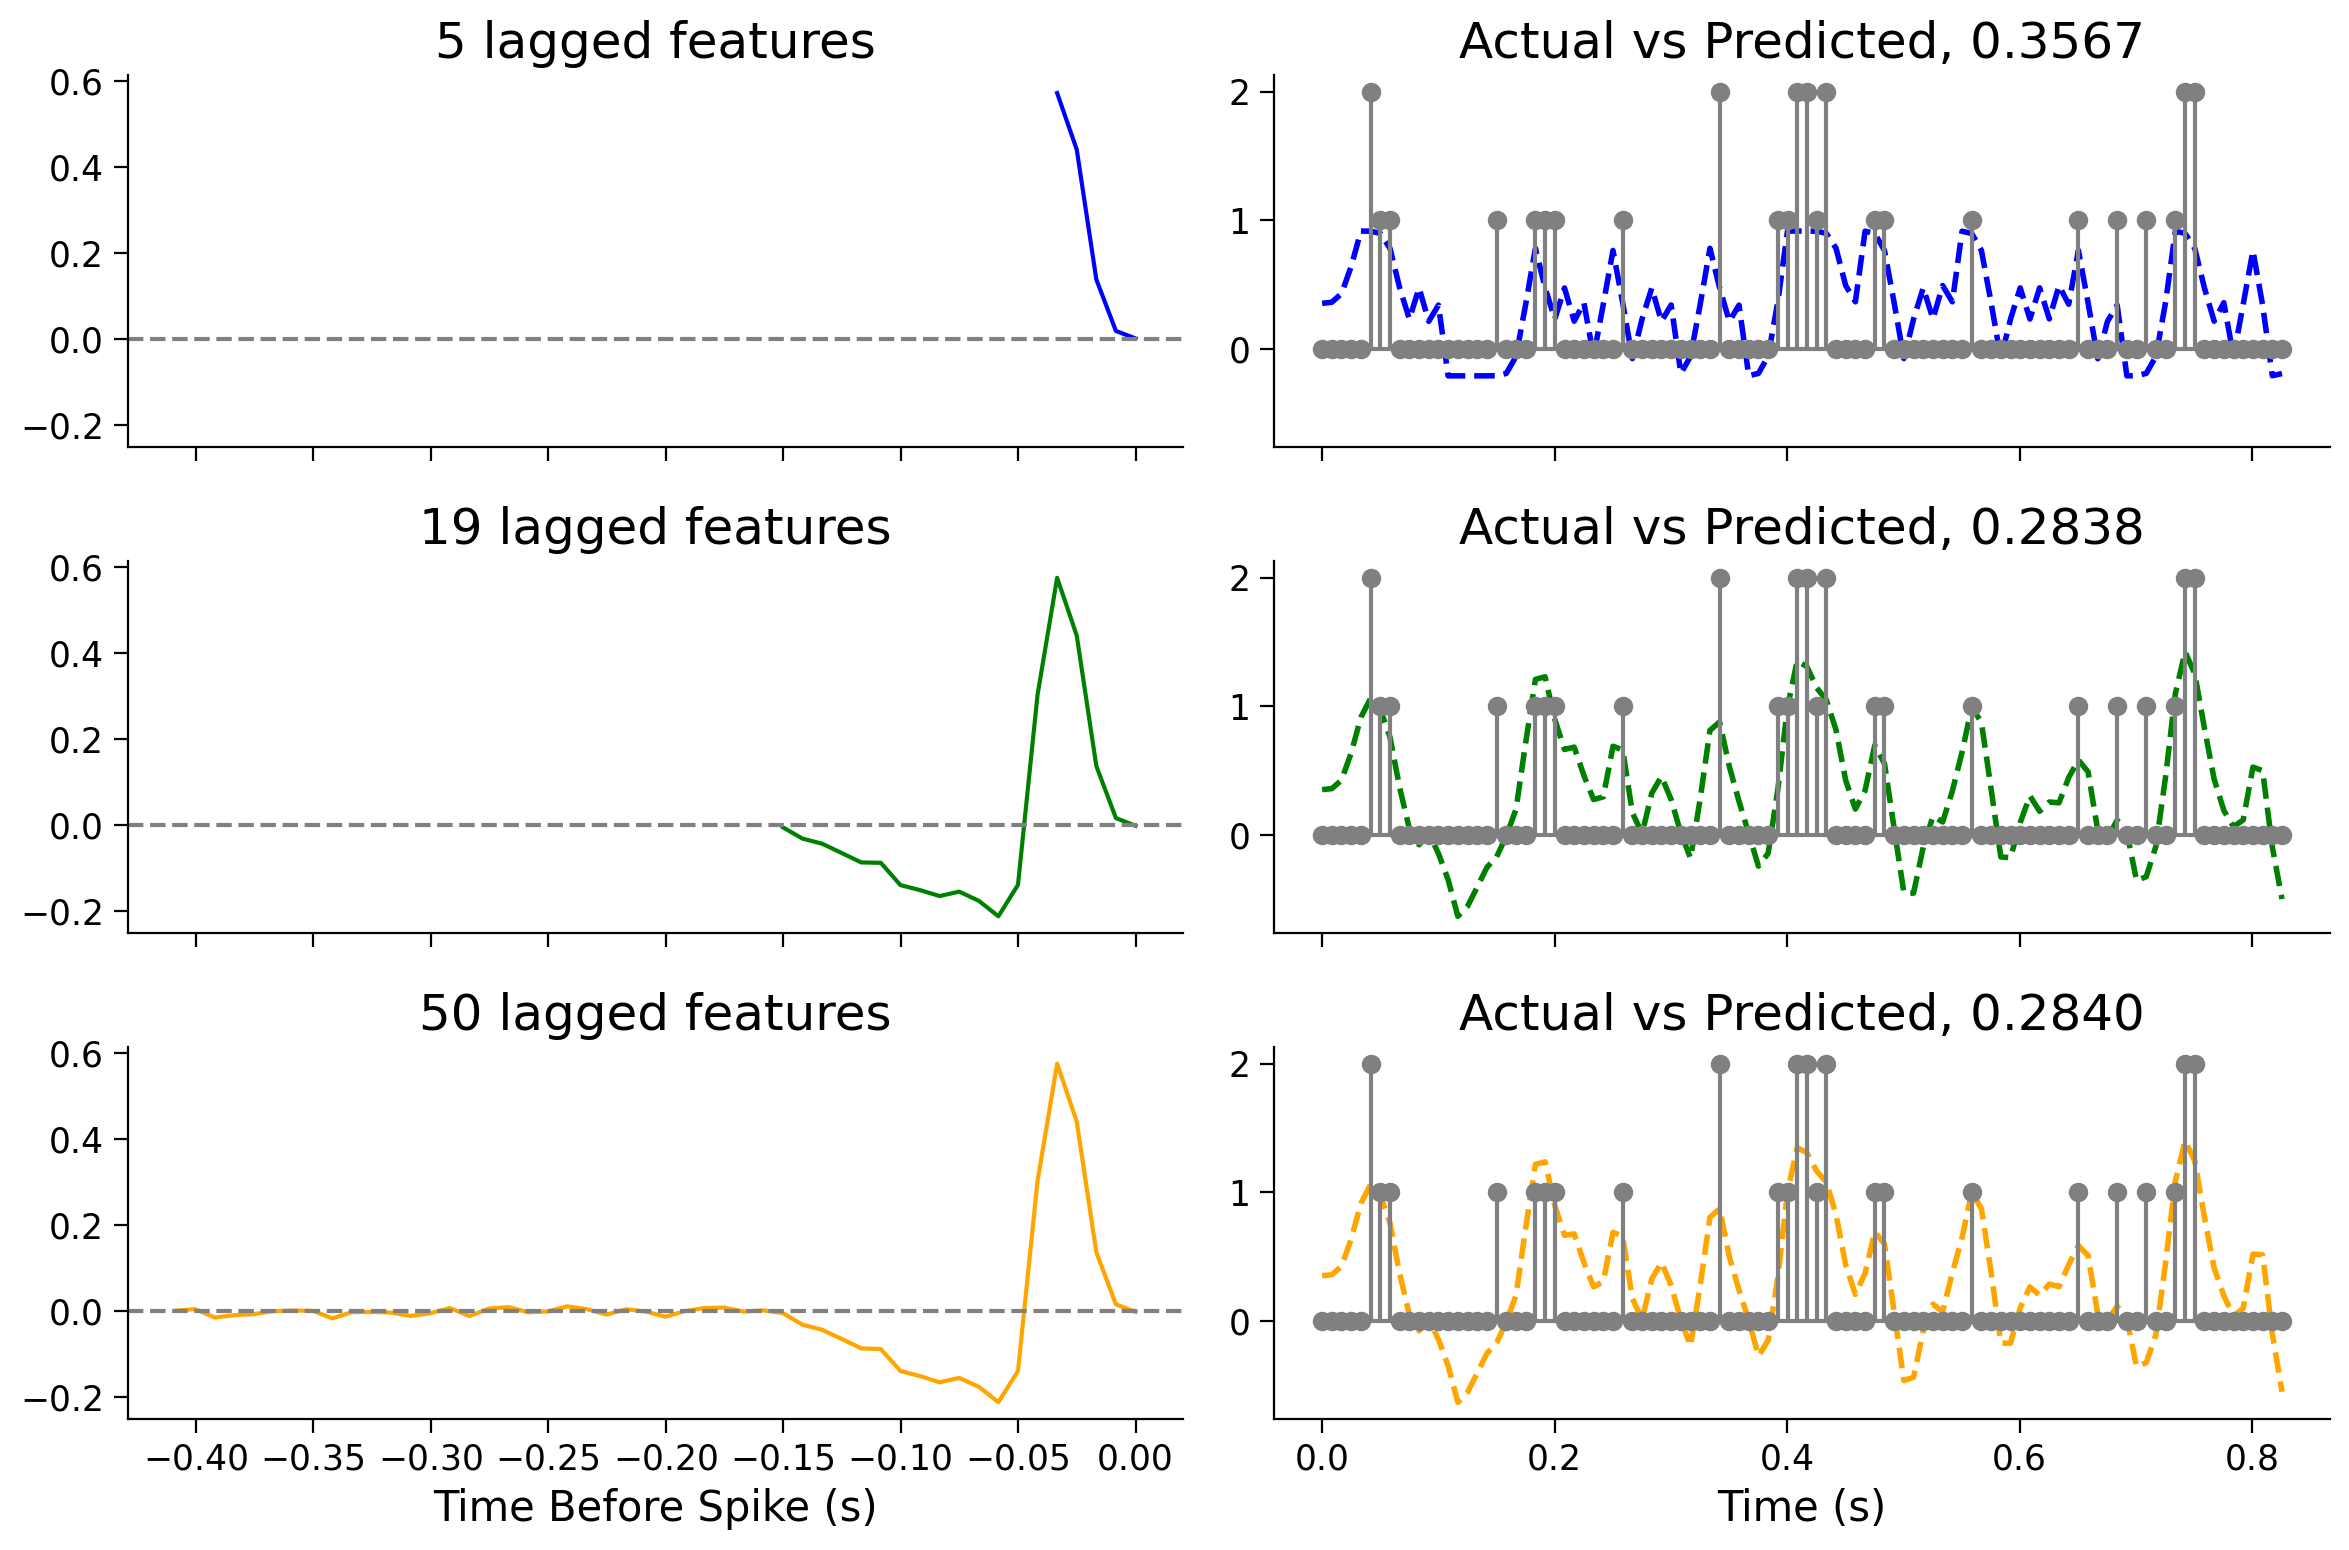

In [ ]:
# Plot filters from above against each other
fig, axs = plt.subplots(3, 2, figsize=(12, 8), sharex='col', sharey='col')
nt = 100 # Number of time bins to plot
t_pred = np.arange(nt) * dt_stim # Use a separate time variable for predictions
colors = ['blue', 'green', 'orange']

for row_num, i in enumerate([0, 6, -1]):
  filt = lg_params[i][1:]
  filter_t = np.arange(-lagged_feat_nums[i] + 1, 1) * dt_stim # Time variable for filter
  axs[row_num,0].plot(filter_t, filt, color=colors[row_num])
  # Put a horizontal line at 0 to help with visualization
  axs[row_num,0].axhline(y=0, color='gray', linestyle='--')
  axs[row_num,0].set_title(f'{lagged_feat_nums[i]} lagged features')

  preds = lg_predictions[i]
  axs[row_num,1].plot(t_pred, preds[:nt], '--',
           label=f'{lagged_feat_nums[i]} lagged features',
           linewidth=2, color=colors[row_num])
  axs[row_num, 1].set_title(f'Actual vs Predicted, {lg_MSEs[i]:.4f}')
  # Plot actual spikes
  lines = axs[row_num,1].stem(t_pred, eval_spikes[:nt], label='Actual Spikes')
  plt.setp(lines, color=".5")

# Formatting and labeling
axs[-1, 0].set_xlabel('Time Before Spike (s)')
axs[-1, 1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

#### <font color="red">Question:</font>
How do the predictions change as you add more lagged features?

At what point would more lagged features be negligible for performance (Hint: Look at the profile of the MSE vs # of Lagged Features curve?) How does this point relate to the trained filter values?

---
# Section 2: Linear-Nonlinear-Poisson GLM


## Section 2.1: Nonlinear optimization with `scipy.optimize`


Before diving into the Poisson GLM case, let us review the use and importance of convexity in optimization:
- We have seen previously that in the Linear-Gaussian case, maximum likelihood  parameter estimate can be computed analytically. That is great because it only takes us a single line of code!
- Unfortunately in general there is no analytical solution to our statistical estimation problems of interest. Instead, we need to apply a nonlinear optimization algorithm to find the parameter values that minimize some *objective function*. This can be extremely tedious because there is no general way to check whether we have found *the optimal solution* or if we are just stuck in some local minimum.
- Somewhere in between these two extremes, the special case of convex objective function is of great practical importance. Indeed, such optimization problems can be solved very reliably (and usually quite rapidly too!) using some standard software.

Notes:
- a function is convex if and only if its curve lies below any chord joining two of its points
- to learn more about optimization, you can consult the book of Stephen Boyd and Lieven Vandenberghe [Convex Optimization](https://web.stanford.edu/~boyd/cvxbook/).

Here we will use the `scipy.optimize` module, it contains a function called [`minimize`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) that provides a generic interface to a large number of optimization algorithms. This function expects as argument an objective function and an "initial guess" for the parameter values. It then returns a dictionary that includes the minimum function value, the parameters that give this minimum, and other information.

Let's see how this works with a simple example. We want to minimize the function $f(x) = x^2$:

In [ ]:
f = np.square
res = minimize(f, x0=2)
print(f"Minimum value: {res['fun']:.4g} at x = {res['x'].item():.5e}")

Minimum value: 3.566e-16 at x = -1.88846e-08


When minimizing a $f(x) = x^2$, we get a minimum value of $f(x) \approx 0$ when $x \approx 0$. The algorithm doesn't return exactly $0$, because it stops when it gets "close enough" to a minimum. You can change the `tol` parameter to control how it defines "close enough".

A point about the code bears emphasis. The first argument to `minimize` is not a number or a string but a *function*. Here, we used `np.square`. Take a moment to make sure you understand what's going on, because it's a bit unusual, and it will be important for the exercise you're going to do in a moment.

In this example, we started at $x_0 = 2$. Let's try different values for the starting point:

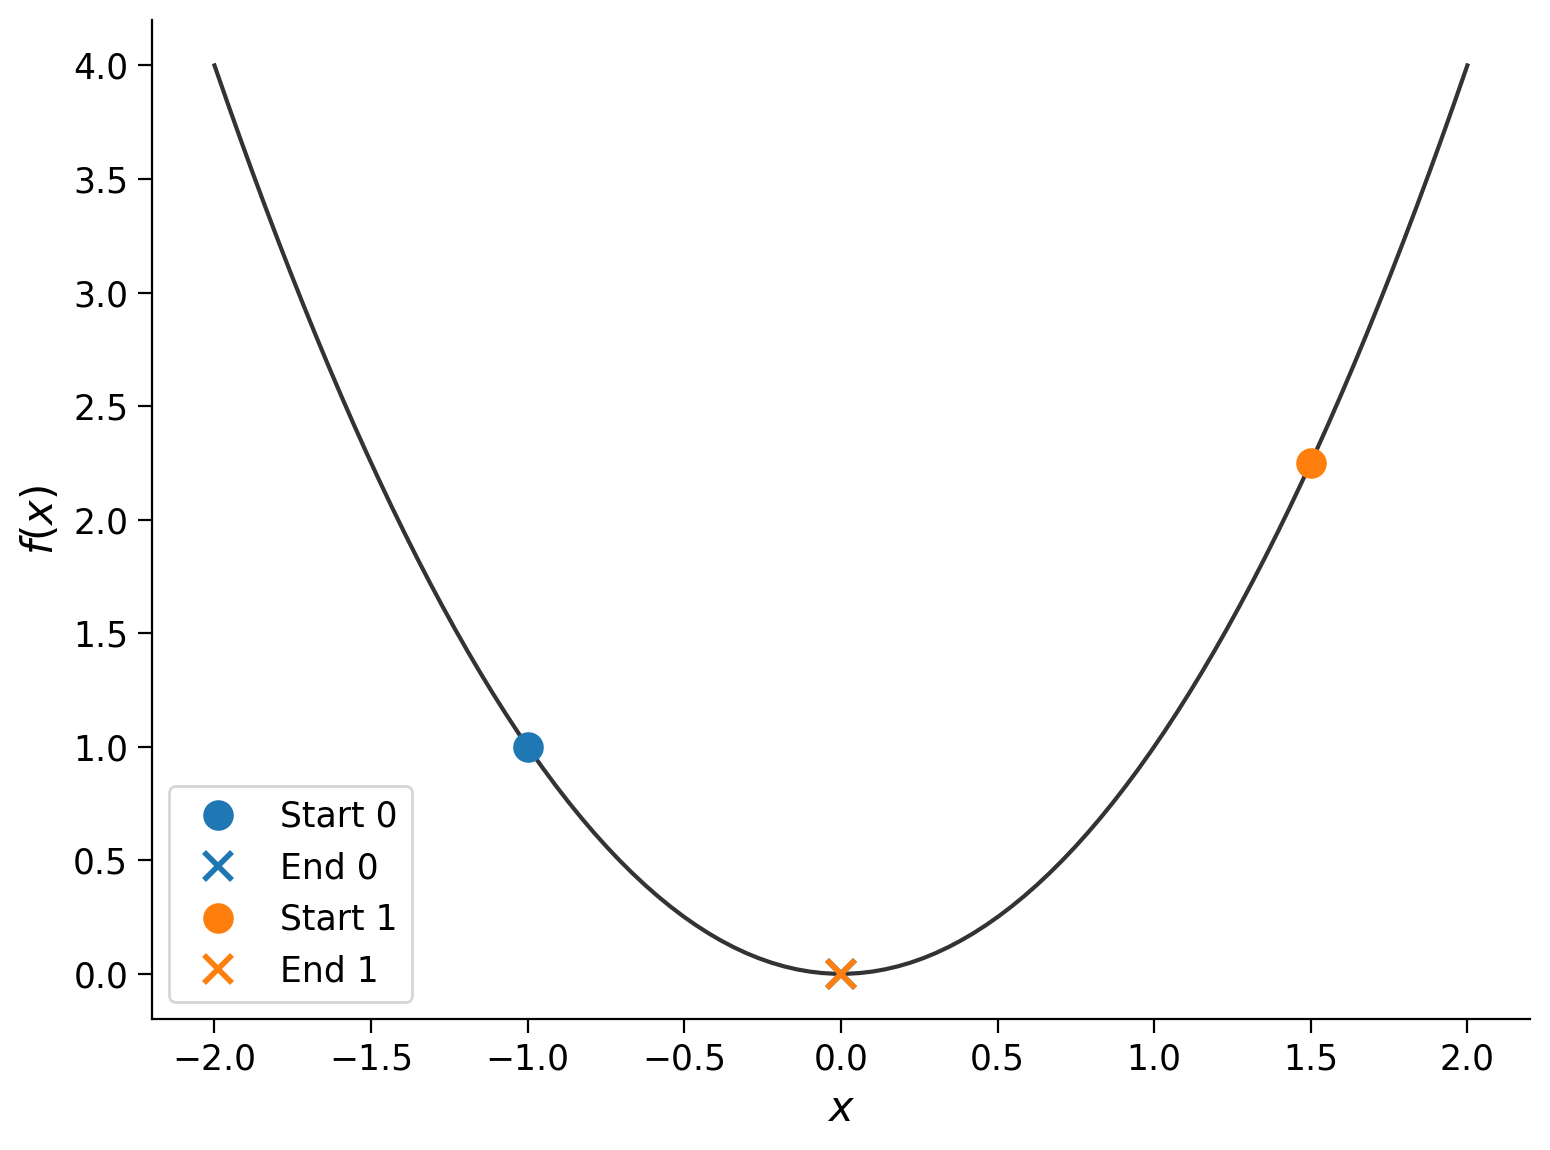

In [ ]:
start_points = -1, 1.5

xx = np.linspace(-2, 2, 100)
plt.plot(xx, f(xx), color=".2")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")

for i, x0 in enumerate(start_points):
  res = minimize(f, x0)
  plt.plot(x0, f(x0), "o", color=f"C{i}", ms=10, label=f"Start {i}")
  plt.plot(res["x"].item(), res["fun"], "x", c=f"C{i}",
           ms=10, mew=2, label=f"End {i}")
plt.legend()
plt.show()

The runs started at different points (the dots), but they each ended up at roughly the same place (the cross): $f(x_\textrm{final}) \approx 0$. Let's see what happens if we use a different function:

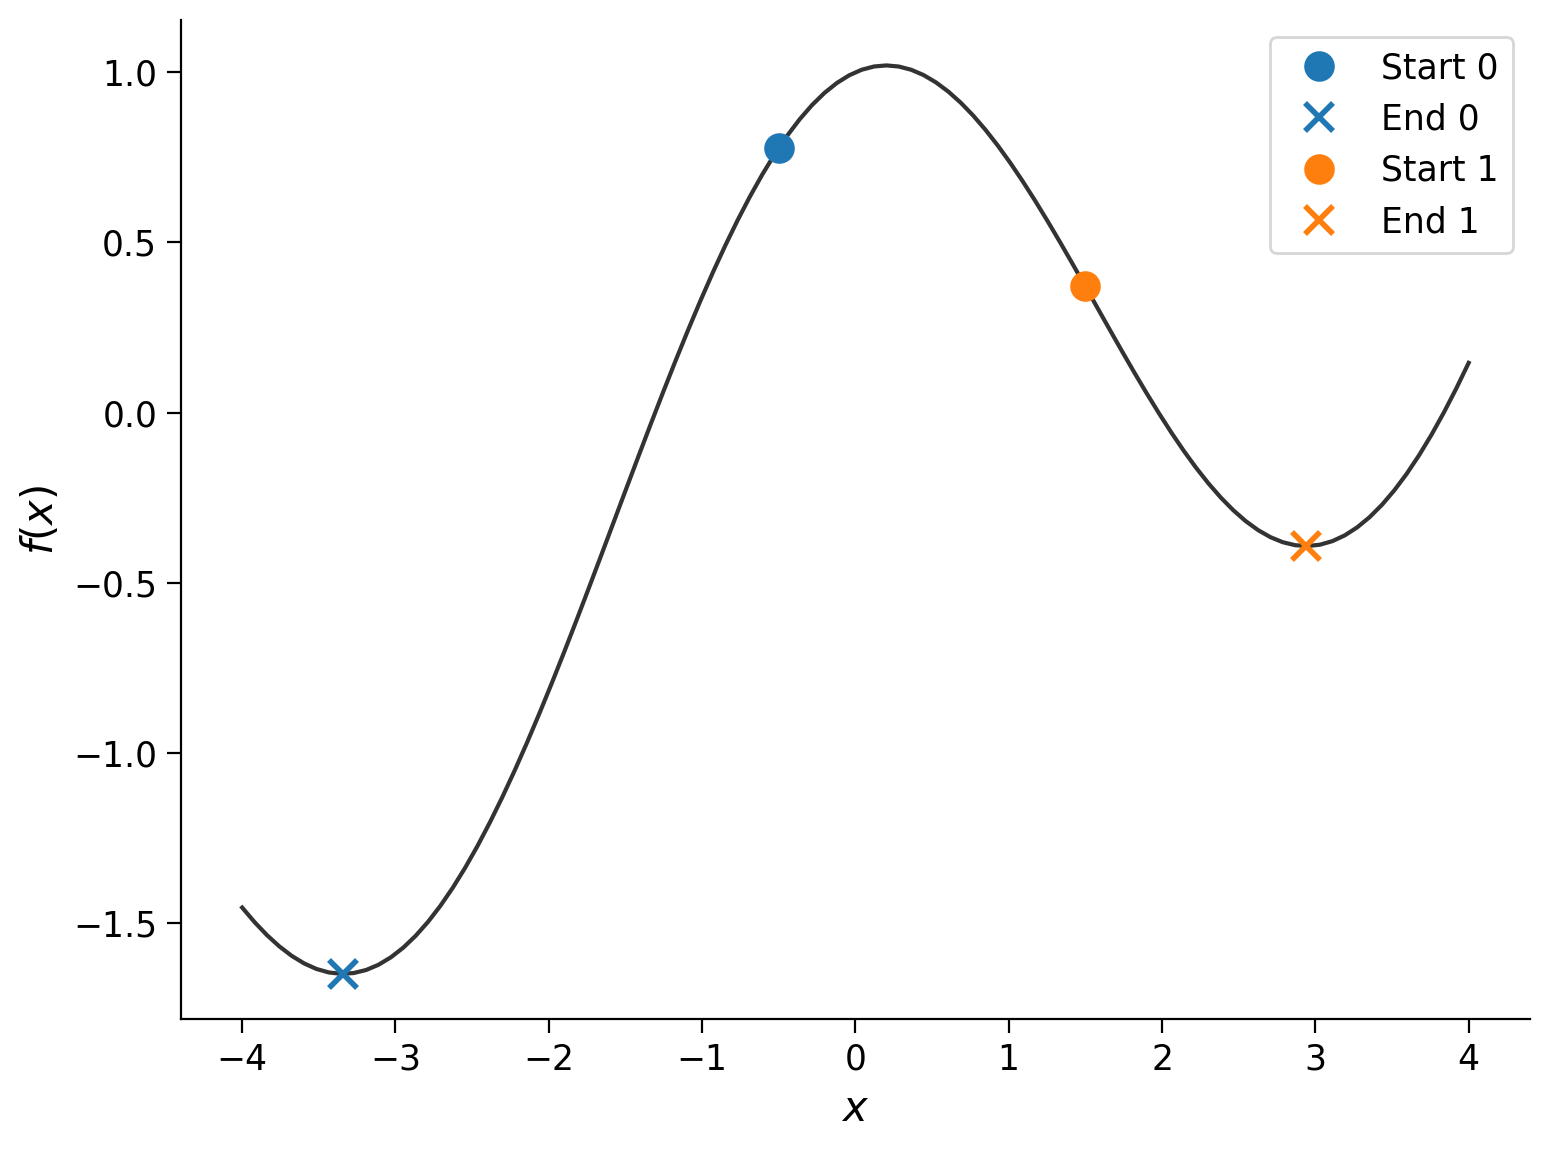

In [ ]:
g = lambda x: x / 5 + np.cos(x)
start_points = -.5, 1.5

xx = np.linspace(-4, 4, 100)
plt.plot(xx, g(xx), color=".2")
plt.xlabel("$x$")
plt.ylabel("$f(x)$")

for i, x0 in enumerate(start_points):
  res = minimize(g, x0)
  plt.plot(x0, g(x0), "o", color=f"C{i}", ms=10, label=f"Start {i}")
  plt.plot(res["x"].item(), res["fun"], "x", color=f"C{i}",
           ms=10, mew=2, label=f"End {i}")
plt.legend()
plt.show()

Unlike $f(x) = x^2$, $g(x) = \frac{x}{5} + \cos(x)$ is not *convex*. We see that the final position of the minimization algorithm depends on the starting point, which adds a layer of complexity to such problems.

### Coding Exercise 2.1: Fitting the Poisson GLM and prediction spikes

In this exercise, we will use [`scipy.optimize.minimize`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html) to compute maximum likelihood estimates for the filter weights in the Poisson GLM model with an exponential nonlinearity (LNP: Linear-Nonlinear-Poisson).

In practice, this will involve filling out two functions.

- The first should be an *objective function* that takes a design matrix, a spike count vector, and a vector of parameters. It should return a negative log likelihood.
- The second function should take `stim` and `spikes`, build the design matrix and then use `minimize` internally, and return the MLE parameters.

What should the objective function look like? We want it to return the negative log likelihood: $-\log P(y \mid \mathbf{X}, \theta).$

In the Poisson GLM,

\begin{equation}
\log P(\mathbf{y} \mid \mathbf{X}, \theta) = \sum_t \log P(y_t \mid \mathbf{x_t},\theta),
\end{equation}

where

\begin{equation}
P(y_t \mid \mathbf{x_t}, \theta) = \frac{\lambda_t^{y_t}\exp(-\lambda_t)}{y_t!} \text{, with rate } \lambda_t = \exp(\mathbf{x_t}^{\top} \theta).
\end{equation}

Now, taking the log likelihood for all the data we obtain:

\begin{equation}
\log P(\mathbf{y} \mid X, \theta) = \sum_t( y_t \log\left(\lambda_t) - \lambda_t - \log(y_t !)\right).
\end{equation}

Because we are going to minimize the negative log likelihood with respect to the parameters $\theta$, we can ignore the last term that does not depend on $\theta$. For faster implementation, let us rewrite this in matrix notation:

\begin{equation}
\mathbf{y}^{\top} \log(\mathbf{\lambda}) - \mathbf{1}^{\top} \mathbf{\lambda} \text{, with  rate } \mathbf{\lambda} = \exp(\mathbf{X} \theta)
\end{equation}

Finally, don't forget to add the minus sign for your function to return the negative log likelihood.

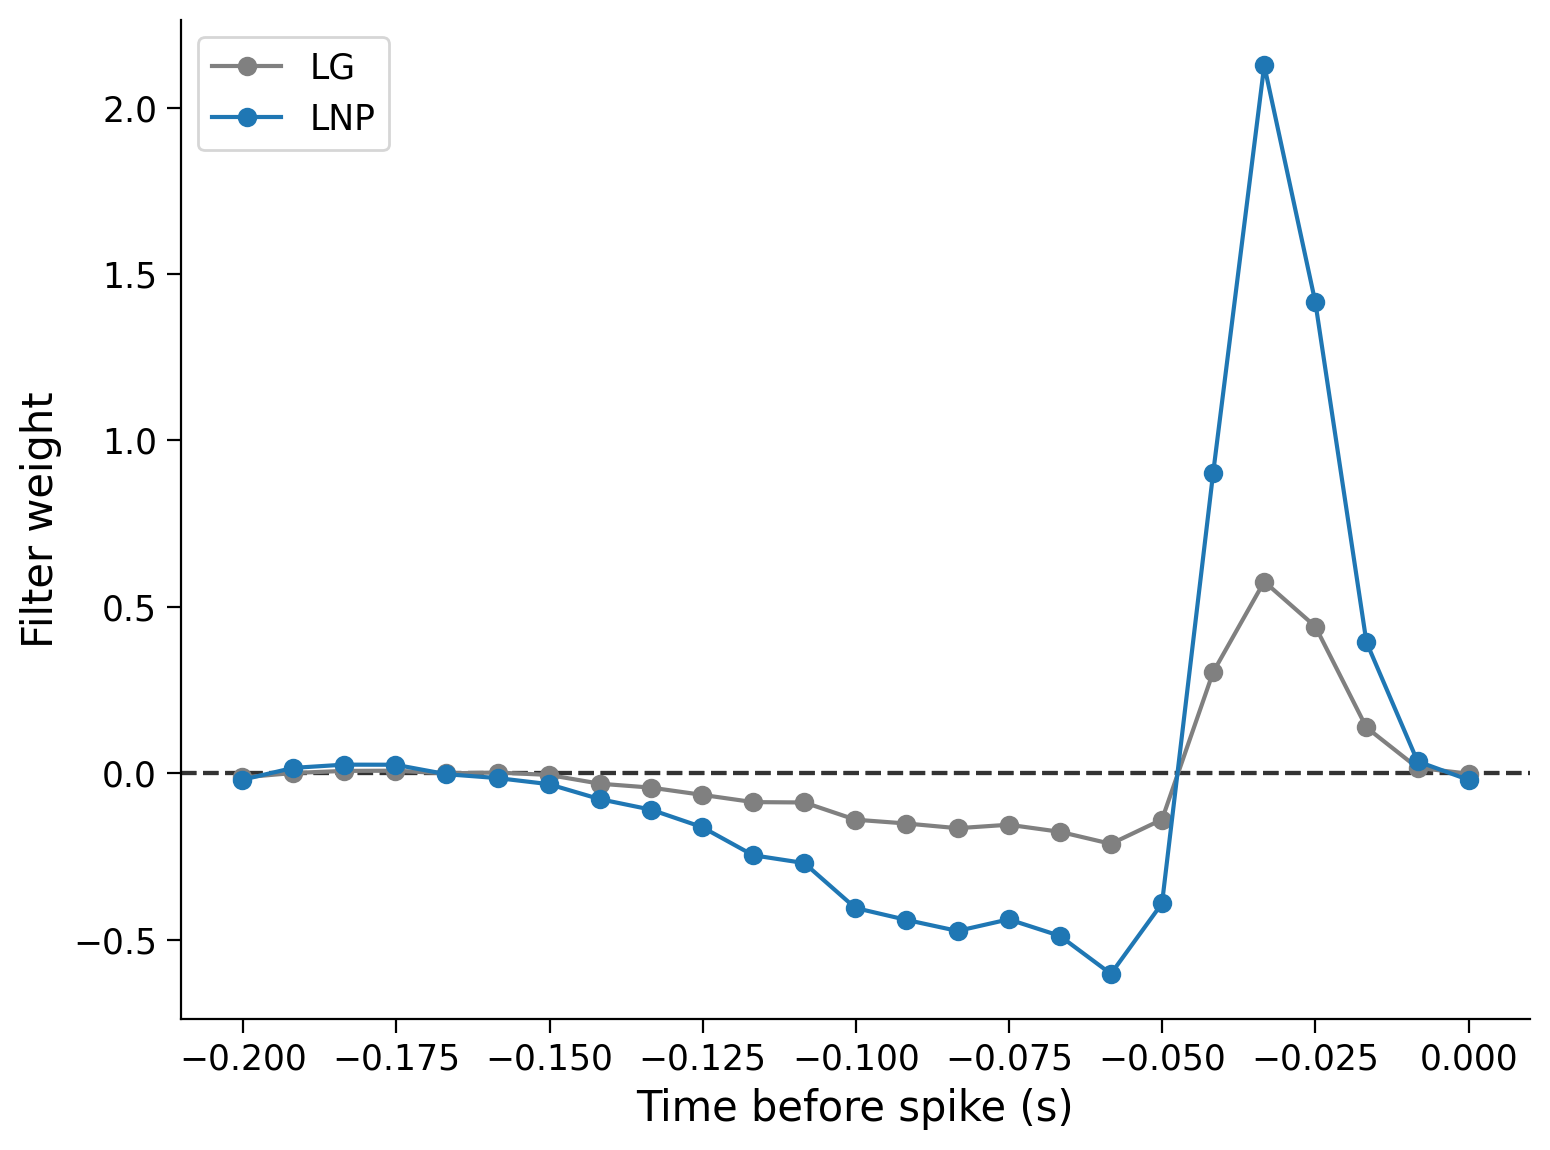

In [ ]:
def calculate_lnp_preds(X, theta):
  """
  Compute the predicted spike counts given the stimulus for a Linear-Nonlinear
  Poisson model.

  Args:
    X (2D array): Complete design matrix with bias
    theta (1D array): model params

  Returns:
    yhat (1D array): Predicted spikes at each timepoint.
  """
  #####################################################################
  # Fill in missing code (...), then remove the error
  raise NotImplementedError("Complete the calculate_lnp_preds function")
  #####################################################################

  return ... #TODO

def neg_log_lik_lnp(theta, X, y):
  """Return -loglike for the Poisson GLM model.

  Args:
    theta (1D array): Parameter vector.
    X (2D array): Full design matrix.
    y (1D array): Data values.

  Returns:
    number: Negative log likelihood.

  """
  #####################################################################
  # Fill in missing code (...), then remove the error
  raise NotImplementedError("Complete the neg_log_lik_lnp function")
  #####################################################################

  # Compute the Poisson log likelihood
  rate = calculate_lnp_preds(X, theta)
  log_lik = ... #TODO

  return -log_lik


def fit_lnp(stim, spikes, d=25):
  """Obtain MLE parameters for the Poisson GLM.

  Args:
    stim (1D array): Stimulus values at each timepoint
    spikes (1D array): Spike counts measured at each timepoint
    d (number): Number of time lags to use.

  Returns:
    1D array: MLE parameters

  """
  #####################################################################
  # Fill in missing code (...), then remove the error
  raise NotImplementedError("Complete the fit_lnp function")
  #####################################################################

  # Build the design matrix
  y = spikes
  X = add_bias_to_design_matrix(stim, spikes, d)

  # Use a random vector of weights to start (mean 0, sd .2)
  x0 = np.random.normal(0, .2, d + 1)

  # Find parameters that minimize the negative log likelihood function
  res = minimize(..., args=(X, y)) #TODO

  return res['x']


# Fit LNP model
theta_lnp = fit_lnp(train_stim, train_spikes, d=25)
lnp_filter = theta_lnp[1:]
# Compare Linear Gaussian and Poisson Filters
plot_spike_filter(lg_filter, dt_stim, show=False, color=".5", label="LG")
plot_spike_filter(lnp_filter, dt_stim, show=False, label="LNP")
plt.legend(loc="upper left")
plt.show()

Plotting the LG and LNP weights together, we see that they are broadly similar, but the LNP weights are generally larger. What does that mean for the model's ability to *predict* spikes? To see that, let's finish the exercise by filling out the `predict_spike_counts_lnp` function:

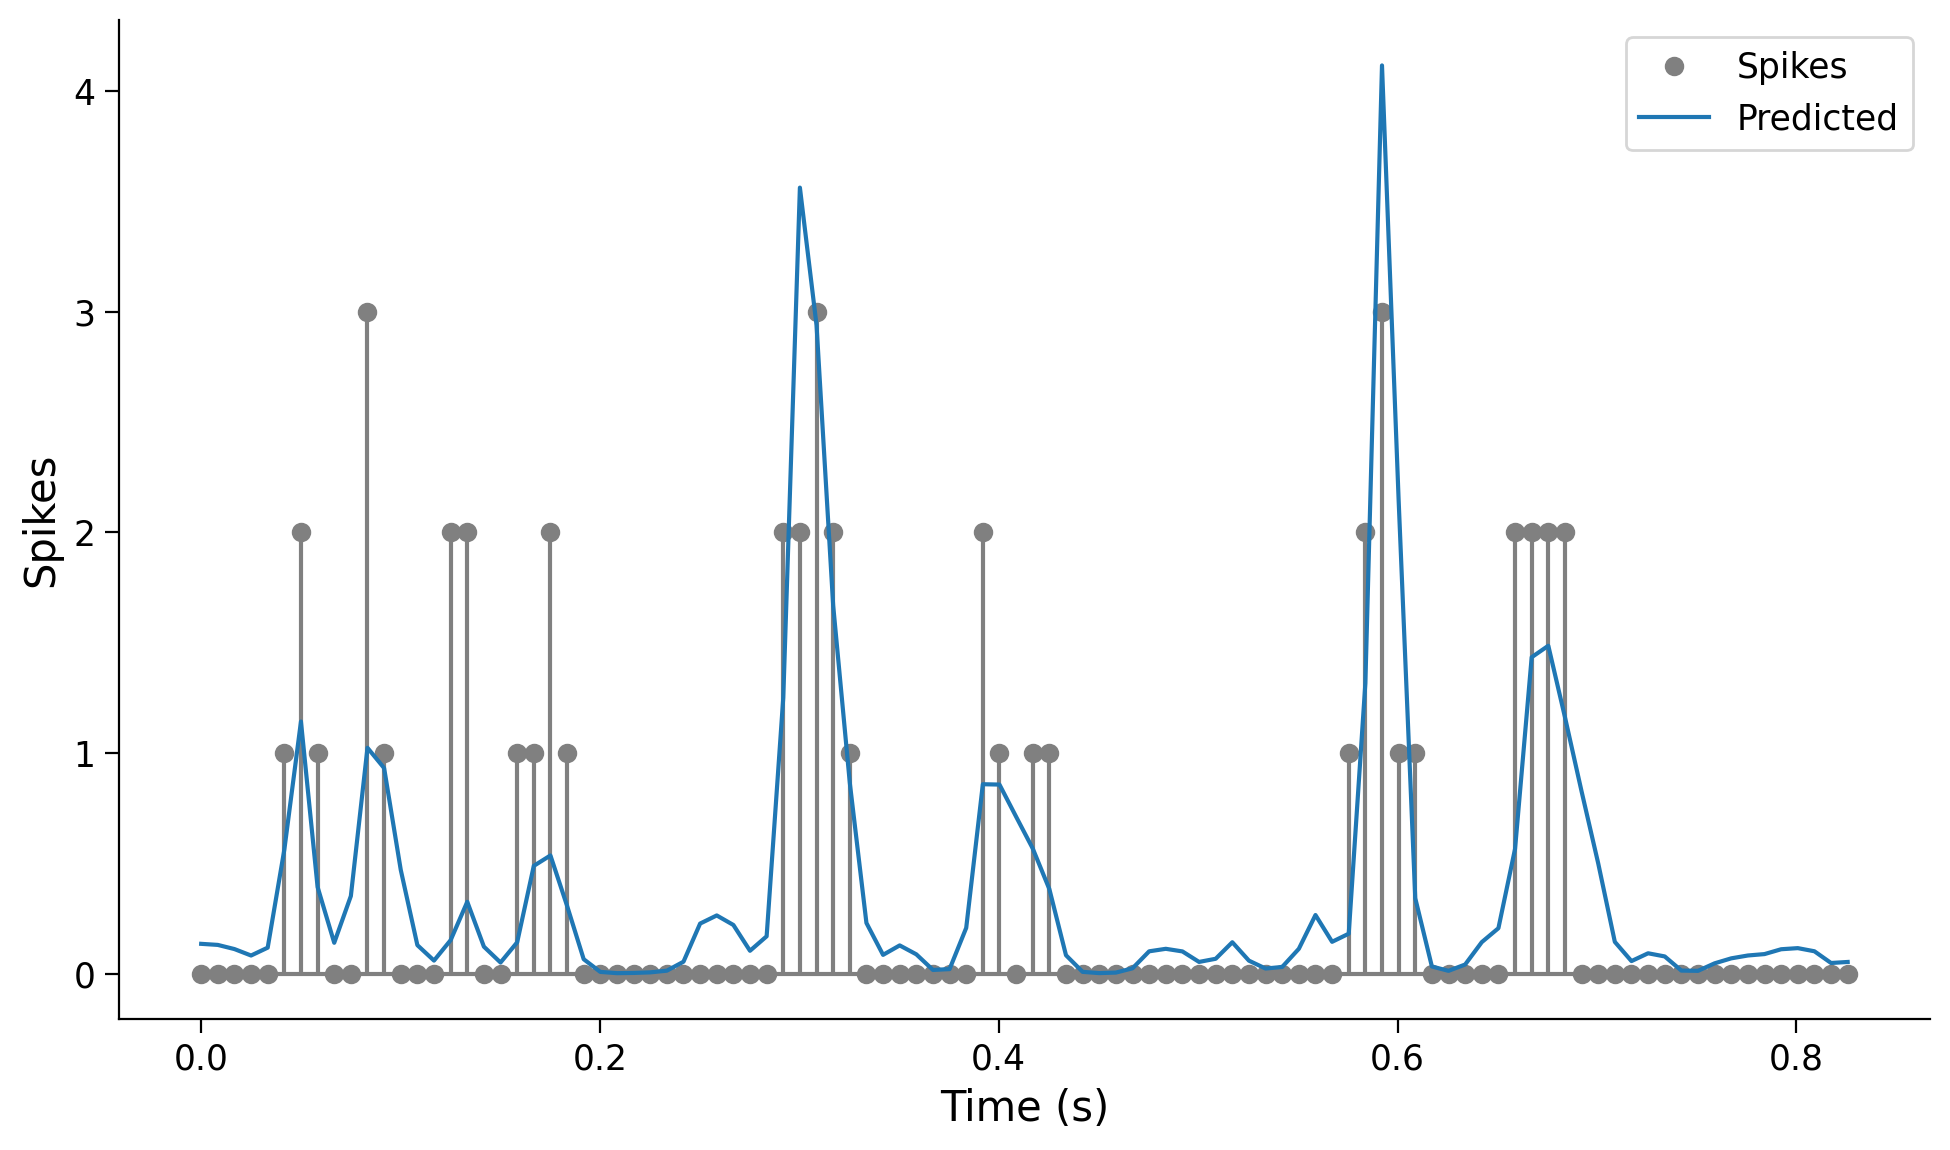

In [ ]:
def predict_spike_counts_lnp(stim, spikes, theta=None, d=25):
  """Compute a vector of predicted spike counts given the stimulus.

  Args:
    stim (1D array): Stimulus values at each timepoint
    spikes (1D array): Spike counts measured at each timepoint
    theta (1D array): Filter weights; estimated if not provided.
    d (number): Number of time lags to use.

  Returns:
    yhat (1D array): Predicted spikes at each timepoint.

  """
  ###########################################################################
  # Fill in missing code (...) and then remove the error to test
  raise NotImplementedError("Complete the predict_spike_counts_lnp function")
  ###########################################################################

  y = spikes
  X = add_bias_to_design_matrix(stim, spikes, d)
  if theta is None:  # Allow pre-cached weights, as fitting is slow
    theta = fit_lnp(stim, spikes, d)

  yhat = ...  #TODO

  return yhat, theta


# Predict spike counts
train_yhat, theta_lnp = predict_spike_counts_lnp(
    train_stim,
    train_spikes,
    theta_lnp,  # Use already calculated filters to speed things up
    d=25
)

# Visualize
plot_spikes_with_prediction(train_spikes, train_yhat, dt_stim, show=False)
plt.title('Linear-Nonlinear-Poisson Predictions vs True Spikes (Training Set)')
plt.show()

We see that the LNP model does a better job of fitting the actual spiking data. Importantly, it never predicts negative spikes!

### Evaluating Linear-Nonlinear Poisson Model Performance for a varying number of lagged features

Here, we will quantitatively evaluate LNP models with different amounts of
lagged features using the MSE metric.

In [ ]:
# (This cell will take some time to complete, ~2 mins)
lnp_MSEs, lnp_predictions, lnp_params = evaluate_model_with_lags(
    ...,  #TODO: What fit function?
    ...,  #TODO: What predict function?
    train_stim,
    train_spikes,
    eval_stim,
    eval_spikes,
    lagged_feat_nums  # Use same lagged feature numbers as in the LG models
)

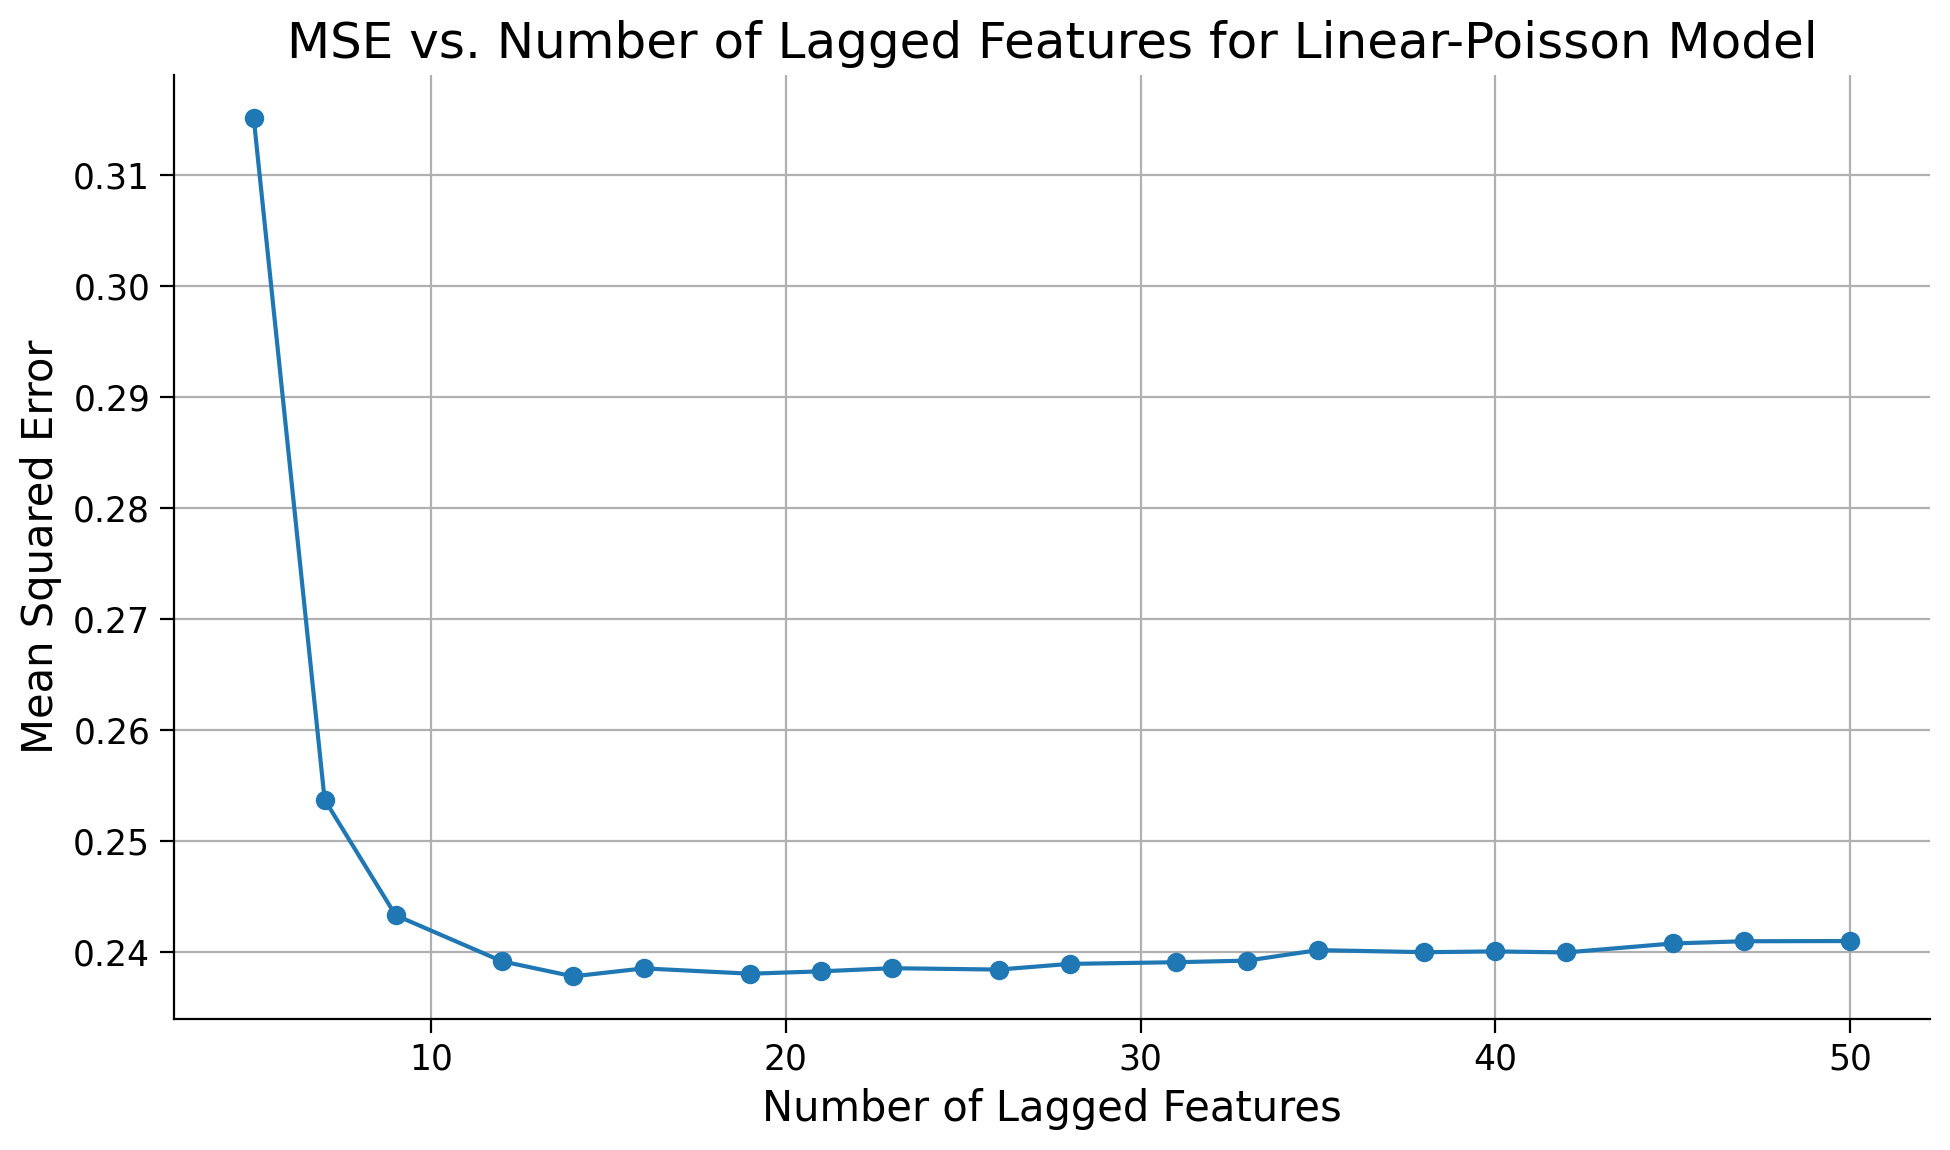

In [ ]:
# Plot MSE vs number of lagged features
plt.figure(figsize=(10, 6))
plt.plot(lagged_feat_nums, lnp_MSEs, marker='o', linestyle='-')

# Labels and formatting
plt.xlabel('Number of Lagged Features')
plt.ylabel('Mean Squared Error')
plt.title('MSE vs. Number of Lagged Features for Linear-Poisson Model')
plt.grid(True)
plt.show()

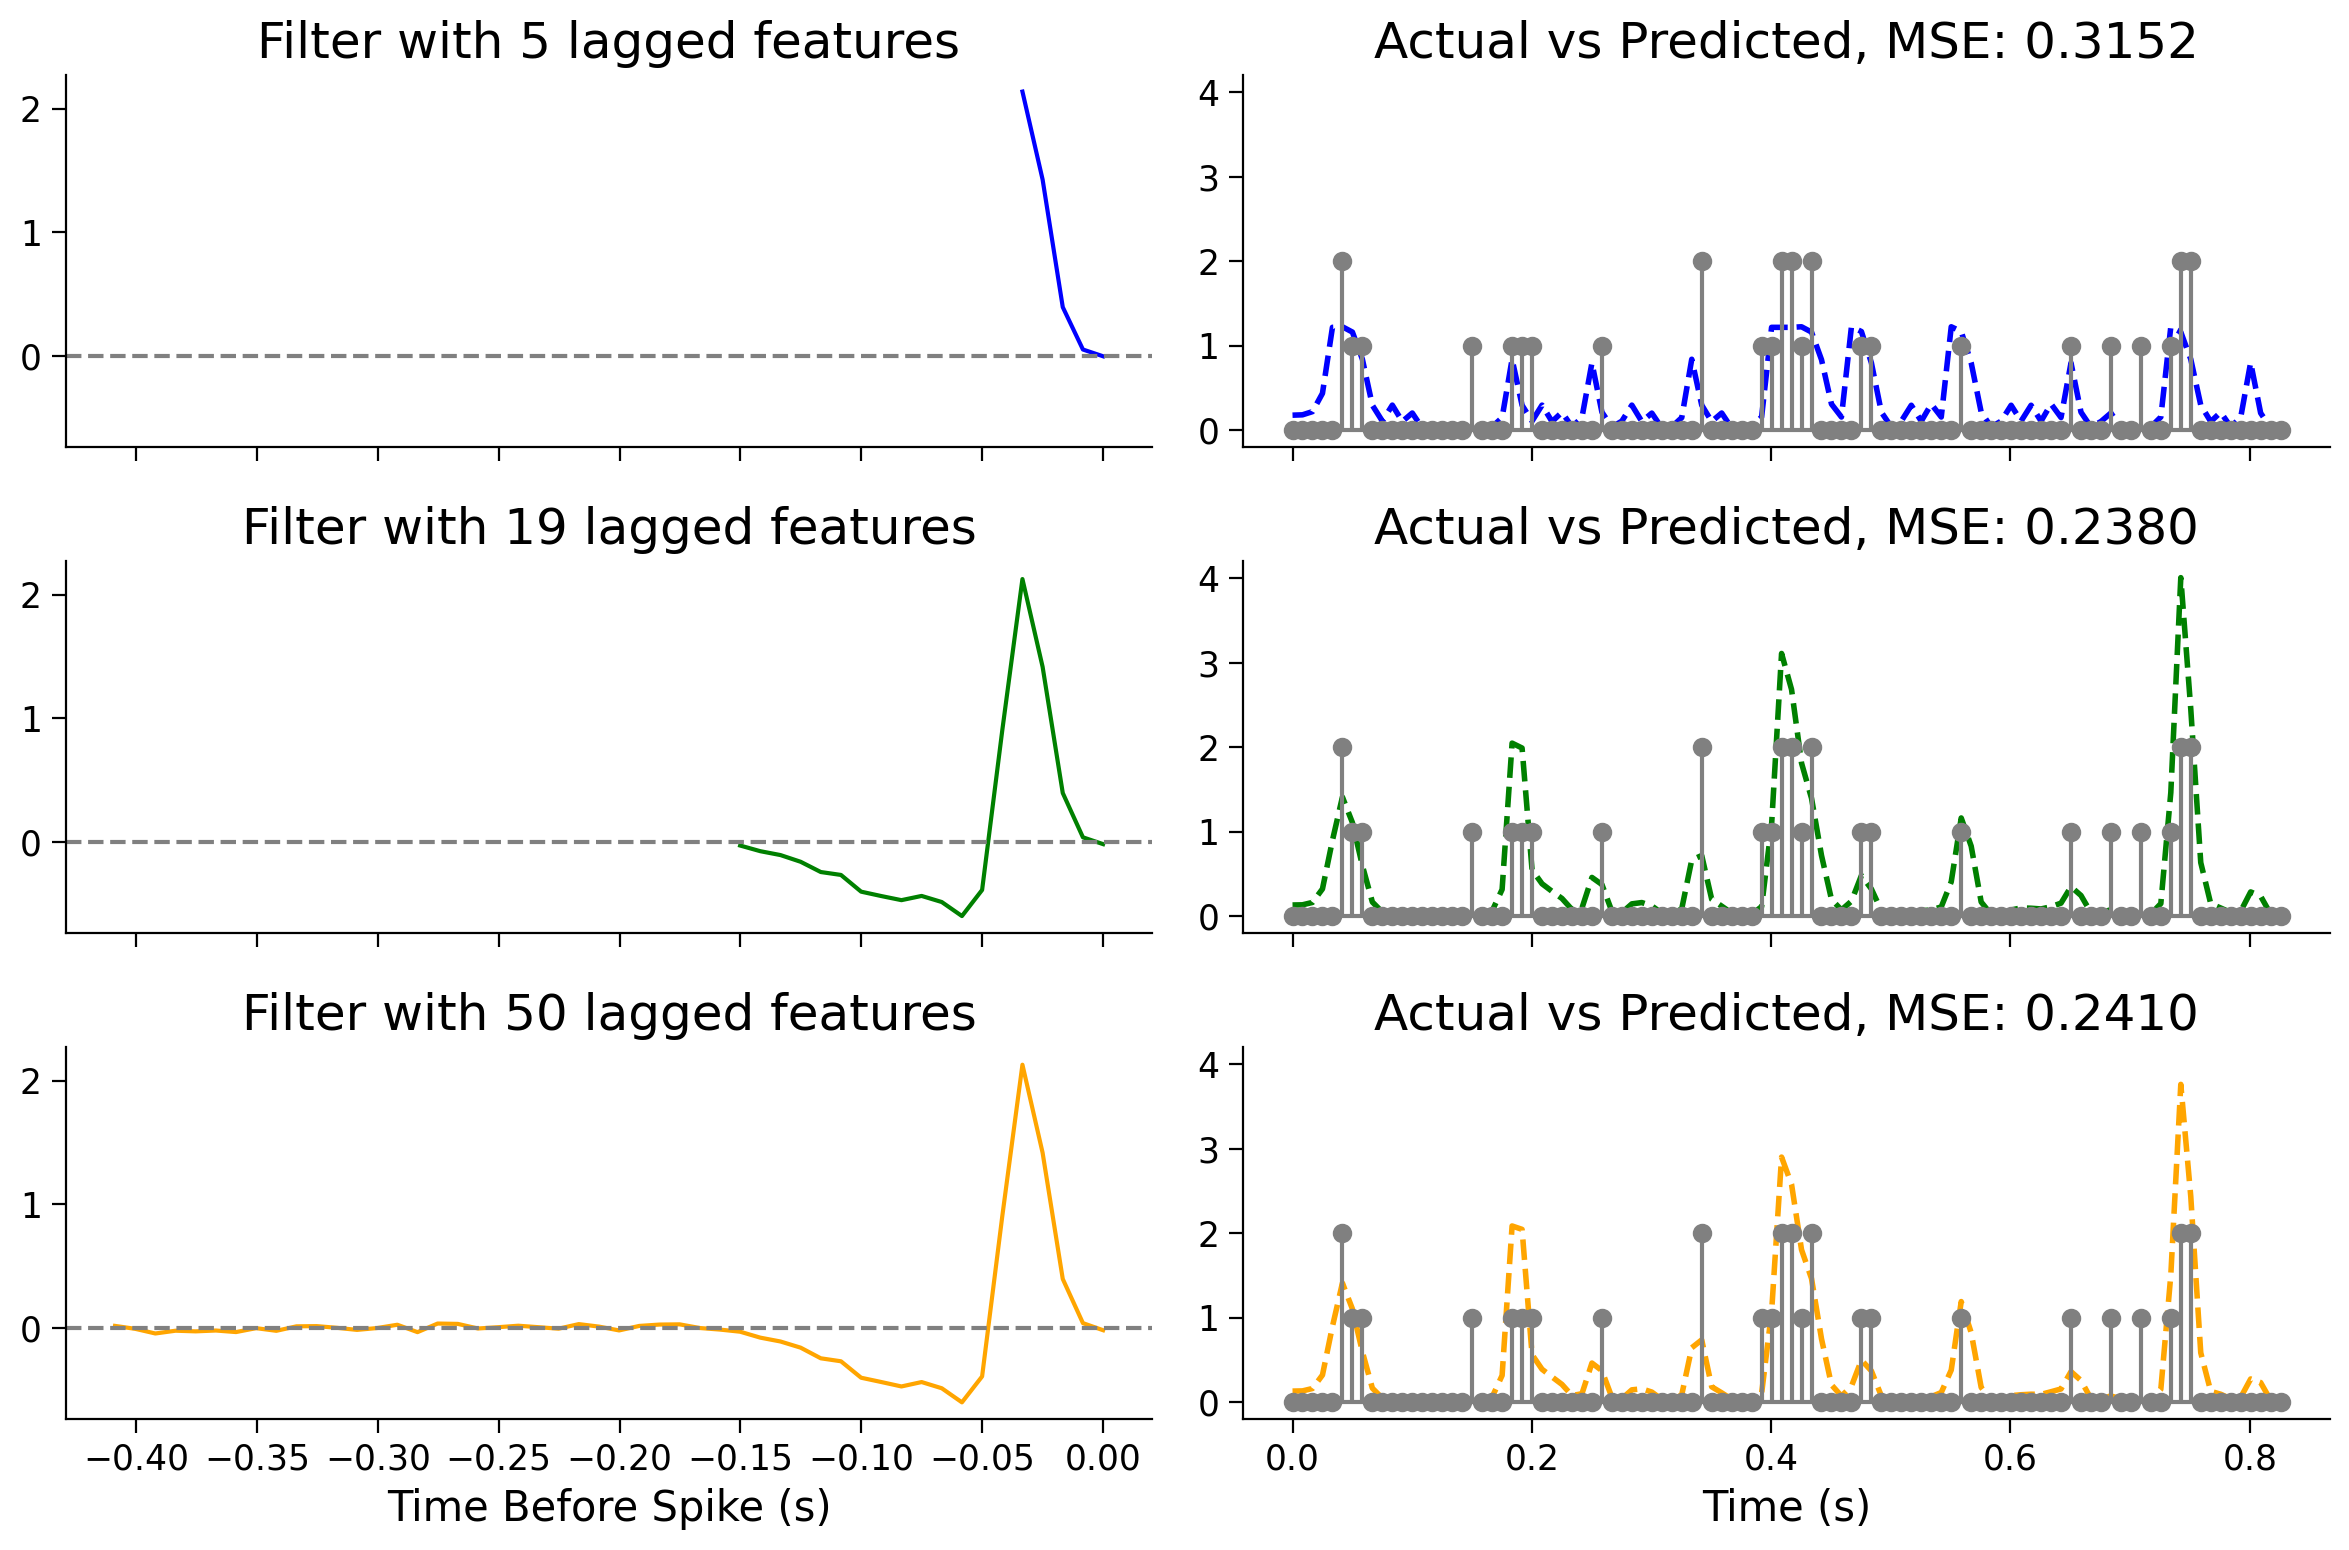

In [ ]:
# Plot filters from above against each other
fig, axs = plt.subplots(3, 2, figsize=(12, 8), sharex='col', sharey='col')
nt = 100 # Number of time bins to plot
t_pred = np.arange(nt) * dt_stim # Use a separate time variable for predictions
colors = ['blue', 'green', 'orange']

for row_num, i in enumerate([0, 6, -1]):
  filt = lnp_params[i][1:]
  filter_t = np.arange(-lagged_feat_nums[i] + 1, 1) * dt_stim # Time variable for filter
  axs[row_num,0].plot(filter_t, filt, color=colors[row_num])
  # Put a horizontal line at 0
  axs[row_num,0].axhline(y=0, color='gray', linestyle='--')
  axs[row_num,0].set_title(f'Filter with {lagged_feat_nums[i]} lagged features')

  preds = lnp_predictions[i]
  axs[row_num,1].plot(t_pred, preds[:nt], '--',
           label=f'{lagged_feat_nums[i]} lagged features',
           linewidth=2, color=colors[row_num])
  axs[row_num, 1].set_title(f'Actual vs Predicted, MSE: {lnp_MSEs[i]:.4f}')
  # Plot actual spikes
  lines = axs[row_num,1].stem(t_pred, eval_spikes[:nt], label='Actual Spikes')
  plt.setp(lines, color=".5")

# Formatting and labeling
axs[-1, 0].set_xlabel('Time Before Spike (s)')
axs[-1, 1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

#### <font color="red">Question:</font>
Again, how do the predictions change with the number of lagged features used?

Looking at the MSE vs # of lagged features curve, why do you think the MSE
is increasing as the # of lagged features gets large? What are some ways of preventing this increase in error from occuring (Think back to regularization methods from Lecture 1)?

How could you change the training data to see a more pronounced increase in the MSE as the number of lagged features increases?

---
# Summary

*Estimated timing of tutorial: 1 hour, 15 minutes*

In this first tutorial, we used two different models to learn something about how retinal ganglion cells respond to a flickering white noise stimulus. We learned how to construct a design matrix that we could pass to different GLMs, and we found that the Linear-Nonlinear-Poisson (LNP) model allowed us to predict spike rates better than a simple Linear-Gaussian (LG) model.

---
# Notation

\begin{align}
y &\quad \text{measurement or response, here: spike count}\\
T &\quad \text{number of time points}\\
d &\quad \text{input dimensionality}\\
\mathbf{X} &\quad \text{design matrix, dimensions: } T \times d\\
\theta &\quad \text{parameter}\\
\hat \theta &\quad \text{estimated parameter}\\
\hat y &\quad \text{estimated response}\\
P(\mathbf{y} \mid \mathbf{X}, \theta) &\quad \text{probability of observing response } y \text{ given design matrix } \mathbf{X} \text{ and parameters } \theta \\
\mathrm{STA} &\quad \text{spike-triggered average}\\
b &\quad \text{bias weight, intercept}\\
\end{align}